# Bayesian Censoring Data Modeling

In this example we show how to model censored data using NumPyro. [*Censoring*](https://en.wikipedia.org/wiki/Censoring_(statistics)) is a condition in which the value of a measurement or observation is only partially known. We work out two examples: a continuous and a discrete likelihood. Both cases follow the same structure but differ in a small detail, which we want to highlight. The key ingredient of the modeling strategy is the [cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function) (CDF) [parametrization](https://forum.pyro.ai/t/censoring-model-observing-on-delta/1811) described in Uber's blog post ["Modeling Censored Time-to-Event Data Using Pyro, an Open Source Probabilistic Programming Language"](https://www.uber.com/en-DE/blog/modeling-censored-time-to-event-data-using-pyro/) (see [here](https://gist.github.com/hesenp/90877ea3d5801214098fecd3b9e089bc) the original gist code). NumPyro now ships this strategy as the built-in censored distributions `LeftCensoredDistribution`, `RightCensoredDistribution`, and `IntervalCensoredDistribution`, so we do not need to implement the censored likelihood from scratch. In this tutorial we use `IntervalCensoredDistribution`, which handles censoring from below and above at the same time.

This example is based in the notebook [Bayesian Censoring Data Modeling](https://juanitorduz.github.io/censoring/).

## Prepare Notebook

In [1]:
!pip install -q numpyro@git+https://github.com/pyro-ppl/numpyro arviz matplotlib preliz pydantic

In [2]:
import os

import arviz as az
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import preliz as pz
from pydantic import BaseModel, Field

from jax import Array, random
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

plt.style.use("bmh")
if "NUMPYRO_SPHINXBUILD" in os.environ:
    set_matplotlib_formats("svg")

plt.rcParams["figure.figsize"] = [8, 6]

numpyro.set_host_device_count(n=4)

rng_key = random.key(seed=0)

assert numpyro.__version__.startswith("0.21.0")

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

/private/tmp/claude-501/-Users-juanitorduz-Documents-numpyro/44996906-d473-49a2-8999-3f915fd51174/scratchpad/nbenv/lib/python3.12/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/private/tmp/claude-501/-Users-juanitorduz-Documents-numpyro/44996906-d473-49a2-8999-3f915fd51174/scratchpad/nbenv/lib/python3.12/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


/private/tmp/claude-501/-Users-juanitorduz-Documents-numpyro/44996906-d473-49a2-8999-3f915fd51174/scratchpad/nbenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part I: Continuous Distribution

We start by considering the continuous case. We assume that we have a dataset of observations $y$ that are censored from below and above at a known thresholds. We want to estimate the parameters of a distribution that generated these observations. We assume that the distribution is a gamma distribution (with parameters $\alpha$ and $\beta$), but the same approach can be used for other distributions.

### Generate Censored Data

We generate data from a gamma distribution and we *clip* the data to be between the thresholds `lower` and `upper`. We then plot the histogram of the data and the true gamma distribution.

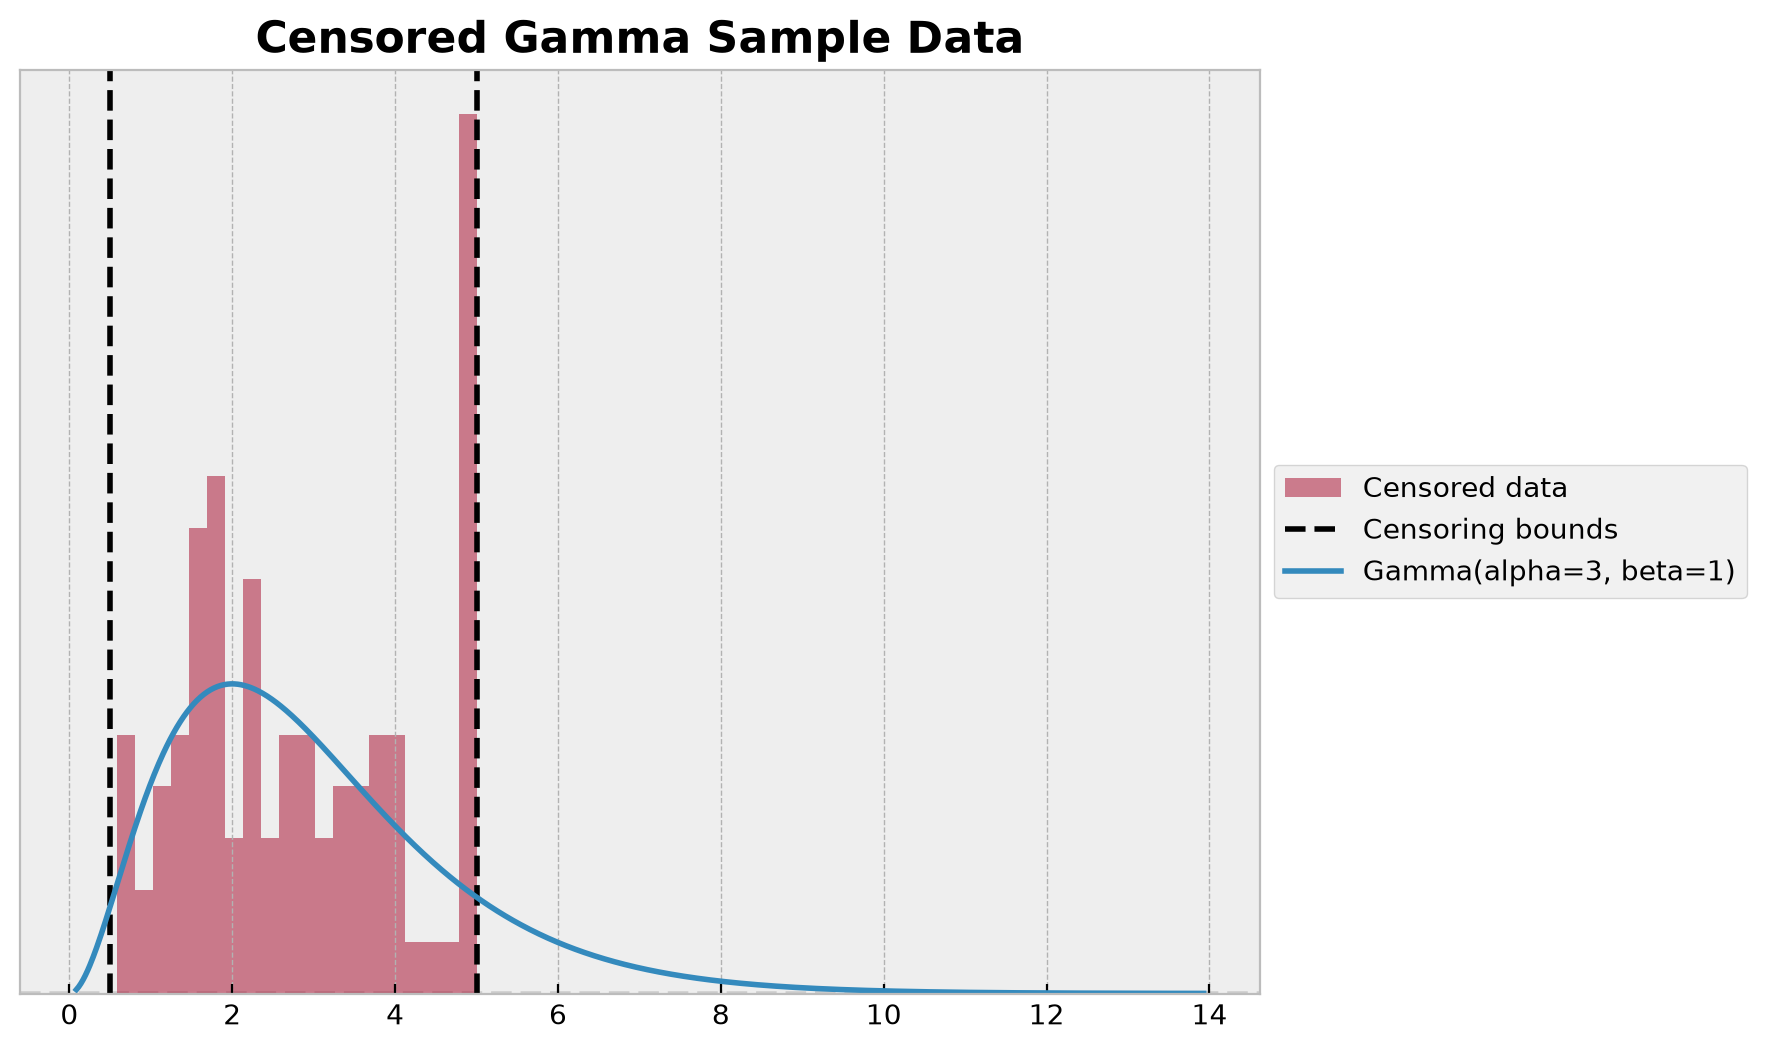

In [3]:
class CensoredGammaDataParams(BaseModel):
    alpha: float = Field(..., description="Concentration parameter", gt=0)
    beta: float = Field(..., description="Rate parameter", gt=0)
    lower: float = Field(..., description="Lower censoring bound", gt=0)
    upper: float = Field(..., description="Upper censoring bound", gt=0)
    n: int = Field(..., description="Number of samples", gt=0)


def generate_censored_gamma_samples(
    rng_key: Array, params: CensoredGammaDataParams
) -> Array:
    raw_samples = dist.Gamma(concentration=params.alpha, rate=params.beta).sample(
        rng_key, (params.n,)
    )
    return jnp.clip(raw_samples, params.lower, params.upper)


censored_gamma_data_params = CensoredGammaDataParams(
    alpha=3.0, beta=1.0, lower=0.5, upper=5.0, n=100
)
rng_key, rng_subkey = random.split(rng_key)
censored_gamma_samples = generate_censored_gamma_samples(
    rng_key=rng_subkey, params=censored_gamma_data_params
)

fig, ax = plt.subplots()
_ = ax.hist(
    censored_gamma_samples,
    bins=20,
    density=True,
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_gamma_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_gamma_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Gamma(
    alpha=censored_gamma_data_params.alpha, beta=censored_gamma_data_params.beta
).plot_pdf(color="C0", ax=ax)
ax.set_title("Censored Gamma Sample Data", fontsize=16, fontweight="bold");

### Naive Model

Before we implement the censoring model, we start with a naive model that does not take into account the censoring component. We simply use a gamma distribution with parameters $\alpha$ and $\beta$ to model the data. We then plot the posterior distribution of the parameters and compare them with the true values.

In [4]:
def gamma_model(y: Array) -> None:
    alpha = numpyro.sample("alpha", dist.Exponential(1.0))
    beta = numpyro.sample("beta", dist.Exponential(1.0))
    numpyro.sample("obs", dist.Gamma(concentration=alpha, rate=beta), obs=y)


class InferenceParams(BaseModel):
    num_warmup: int = Field(2_000, ge=1)
    num_samples: int = Field(3_000, ge=1)
    num_chains: int = Field(4, ge=1)


inference_params = InferenceParams()

gamma_kernel = NUTS(gamma_model)
gamma_mcmc = MCMC(
    gamma_kernel,
    num_warmup=inference_params.num_warmup,
    num_samples=inference_params.num_samples,
    num_chains=inference_params.num_chains,
)
rng_key, rng_subkey = random.split(rng_key)
gamma_mcmc.run(rng_key, y=censored_gamma_samples)

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 1:   0%|          | 0/5000 [00:00<?, ?it/s]

We also generate posterior predictive samples.

In [5]:
gamma_predictive = Predictive(
    model=gamma_model, posterior_samples=gamma_mcmc.get_samples()
)
rng_key, rng_subkey = random.split(rng_key)
gamma_posterior_predictive = gamma_predictive(rng_subkey, y=None)

gamma_idata = az.from_numpyro(posterior=gamma_mcmc)
gamma_idata.extend(az.from_numpyro(posterior_predictive=gamma_posterior_predictive))

Running chain 2:  50%|█████     | 2500/5000 [00:00<00:00, 22371.96it/s]

Running chain 1:  55%|█████▌    | 2750/5000 [00:00<00:00, 23225.82it/s]

Running chain 0:  55%|█████▌    | 2750/5000 [00:00<00:00, 21408.29it/s]

Running chain 3:  55%|█████▌    | 2750/5000 [00:00<00:00, 21557.98it/s]

Running chain 3: 100%|██████████| 5000/5000 [00:00<00:00, 6333.75it/s] 


Running chain 1: 100%|██████████| 5000/5000 [00:00<00:00, 6292.72it/s] 


Running chain 0: 100%|██████████| 5000/5000 [00:00<00:00, 6262.06it/s] 

Running chain 2: 100%|██████████| 5000/5000 [00:00<00:00, 22972.52it/s]

Running chain 2: 100%|██████████| 5000/5000 [00:00<00:00, 6221.18it/s] 

Now we plot the trace and compare the true and estimated parameters.

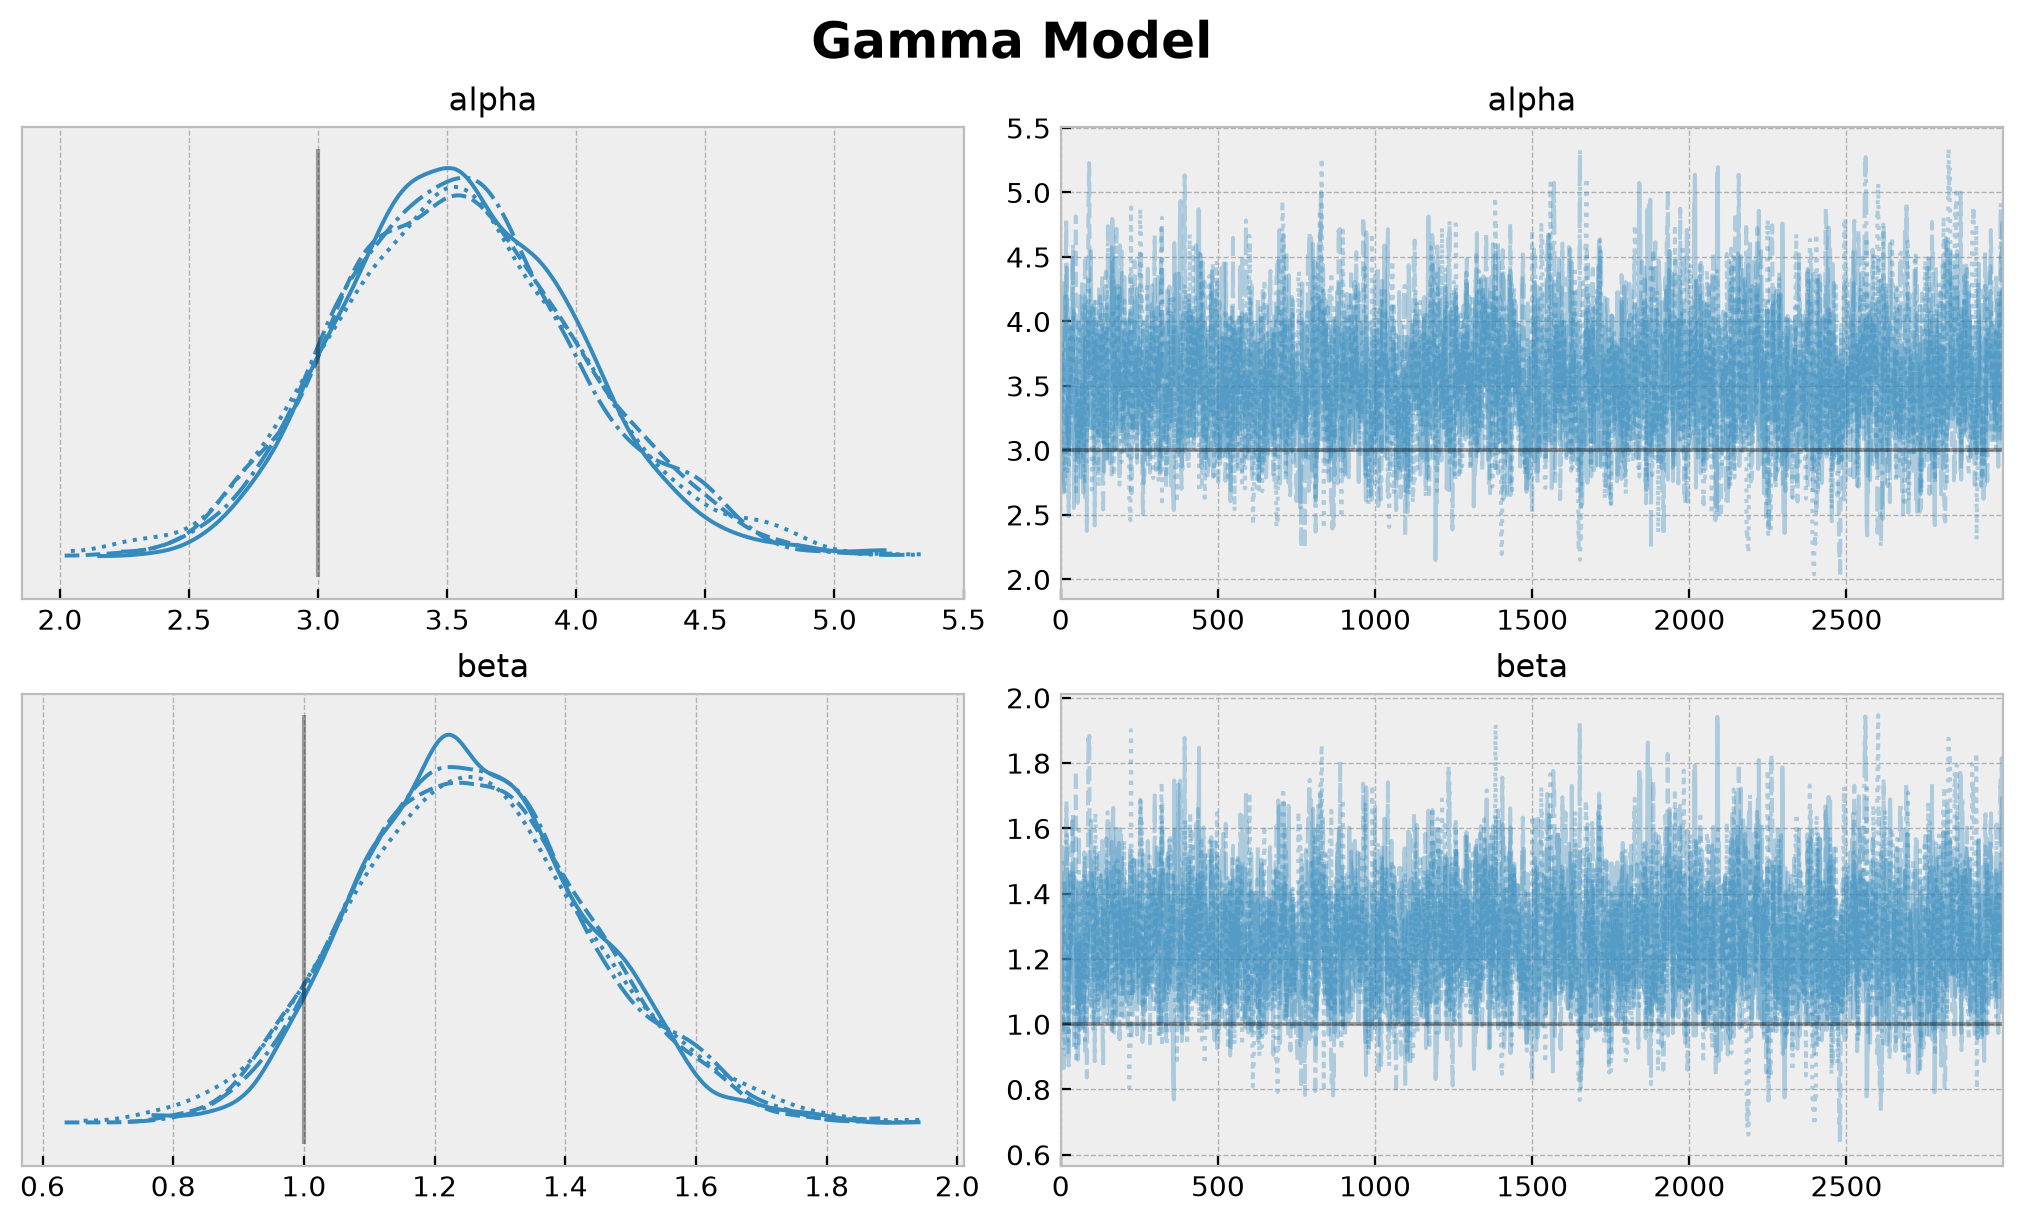

In [6]:
axes = az.plot_trace(
    data=gamma_idata,
    compact=True,
    lines=[
        ("alpha", {}, censored_gamma_data_params.alpha),
        ("beta", {}, censored_gamma_data_params.beta),
    ],
    backend_kwargs={"figsize": (10, 6), "layout": "constrained"},
)
plt.gcf().suptitle("Gamma Model", fontsize=18, fontweight="bold");

findfont: Failed to find font weight semibold, now using 700.


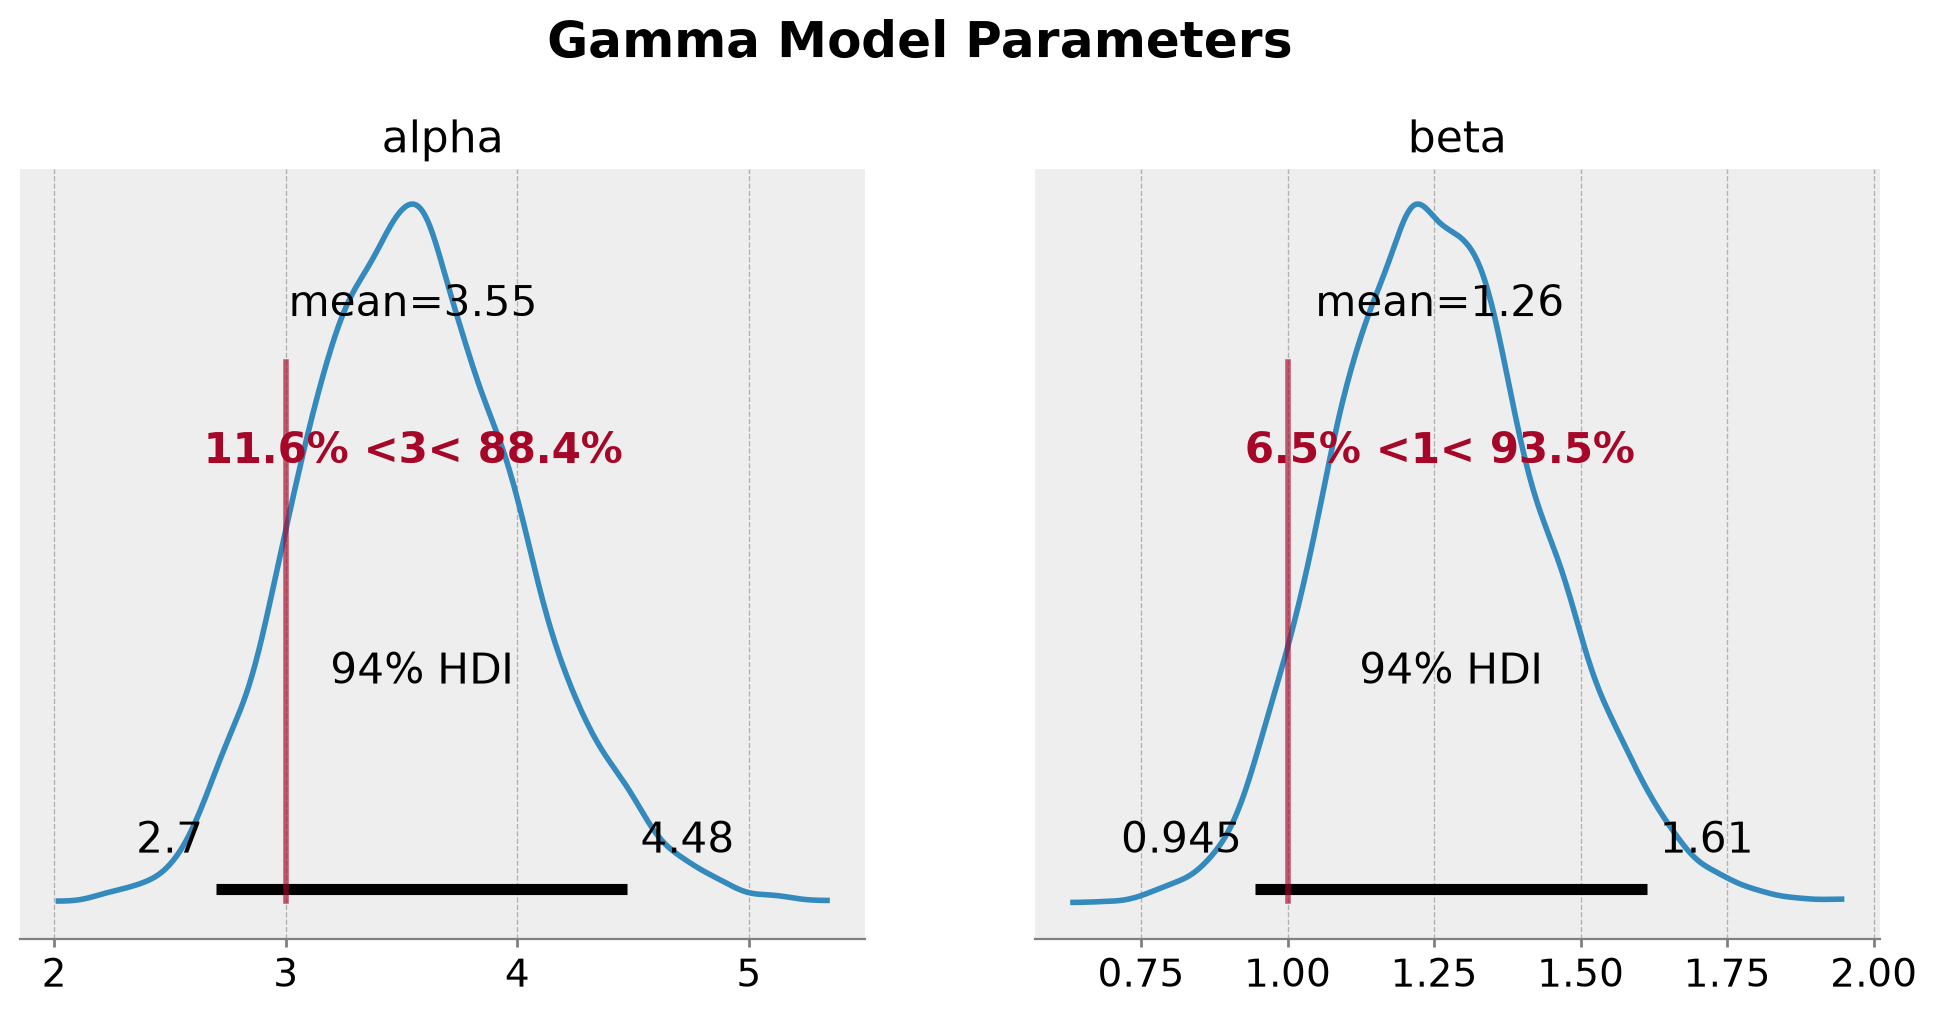

In [7]:
axes = az.plot_posterior(
    data=gamma_idata,
    ref_val=[censored_gamma_data_params.alpha, censored_gamma_data_params.beta],
    round_to=3,
    figsize=(12, 5),
)
plt.gcf().suptitle("Gamma Model Parameters", fontsize=18, fontweight="bold", y=1.03);

Despite the fact that the true parameters are in the $94\%$ HDI, we do see a bias in the estimation of the parameters. This is expected since we are not taking into account the censoring in the model.

We can visualize the inferred distribution and compare it with the true distribution from the data generating process.

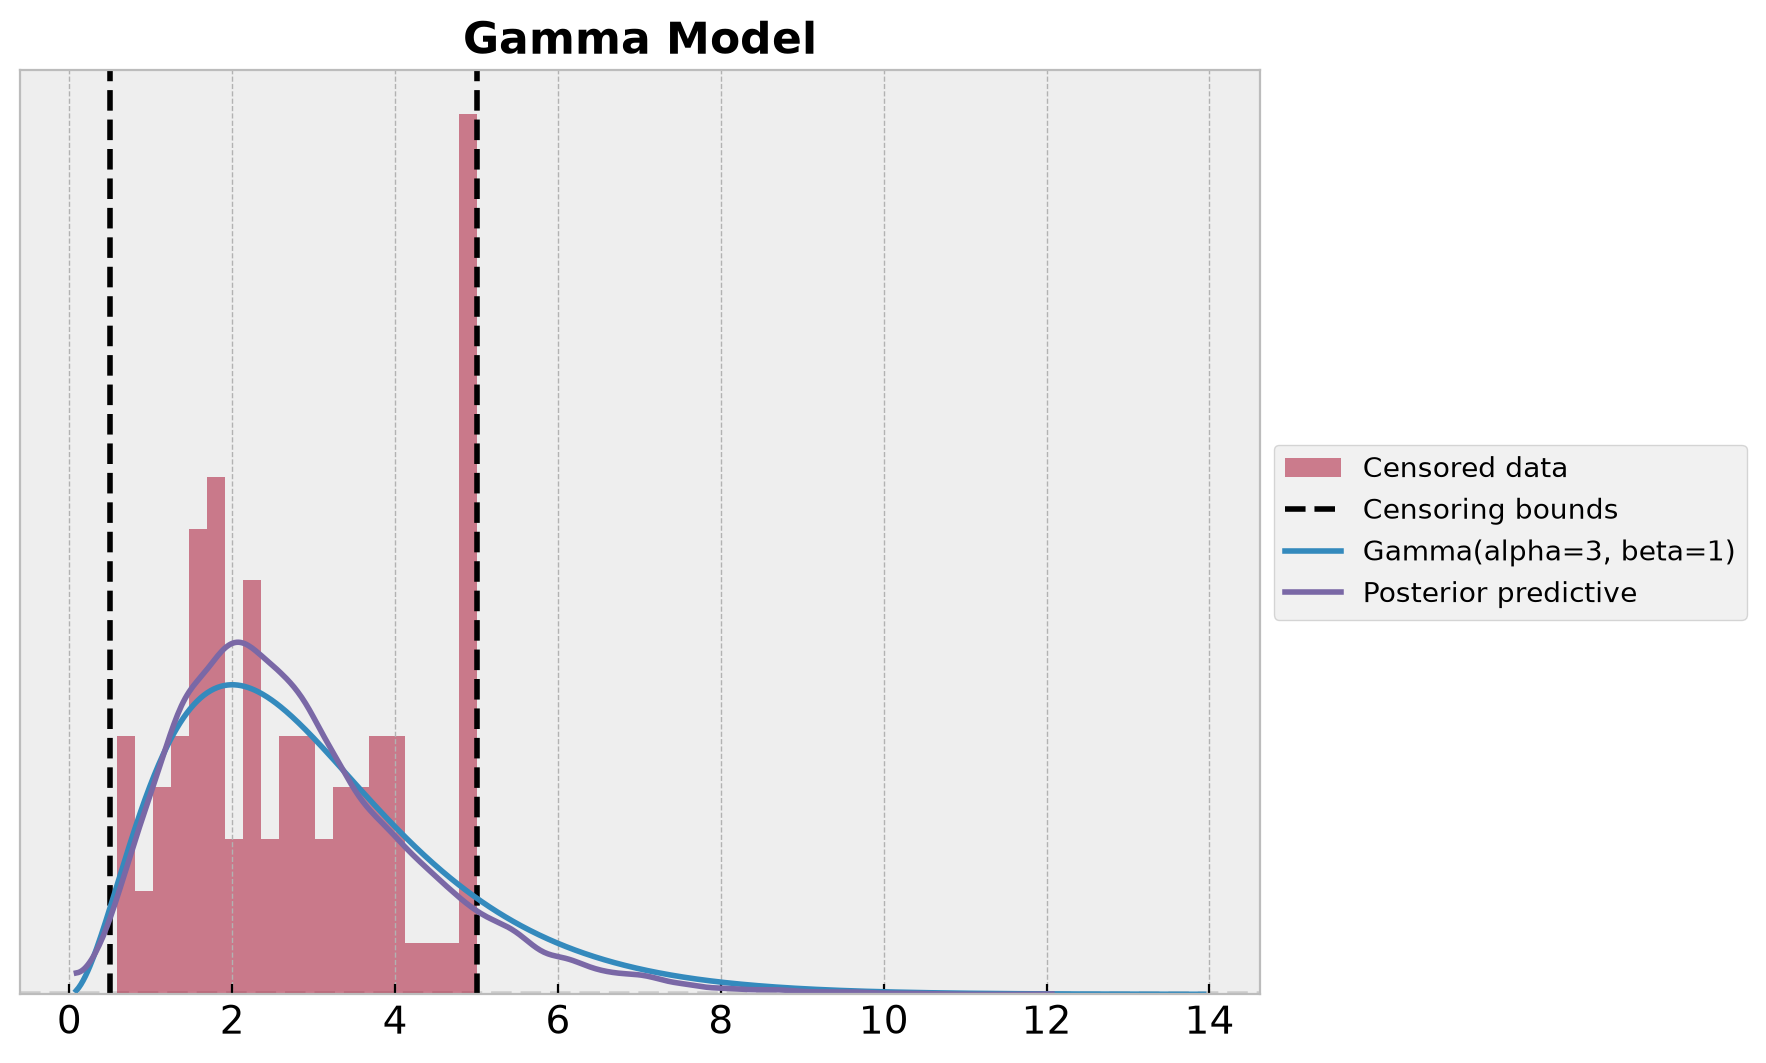

In [8]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_gamma_samples,
    bins=20,
    density=True,
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_gamma_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_gamma_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Gamma(
    alpha=censored_gamma_data_params.alpha, beta=censored_gamma_data_params.beta
).plot_pdf(color="C0", ax=ax)
az.plot_kde(
    gamma_idata["posterior_predictive"]["obs"].to_numpy().flatten(),
    plot_kwargs={"color": "C2", "label": "Posterior predictive"},
    ax=ax,
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Gamma Model", fontsize=16, fontweight="bold");

Here see that the distributions do not match well.

### Censored Gamma Model

As mentioned in the introduction, the main idea to implement the censoring model is to use the CDF parametrization. The reason is because [the probability density function PDF of a censored distribution is](https://www.pymc.io/projects/docs/en/stable/api/distributions/censored.html)

$$
\begin{cases}
    0 & \text{for } y < lower, \\
    \text{CDF}(lower, dist) & \text{for } y = lower, \\
    \text{PDF}(y, dist) & \text{for } lower < y < upper, \\
    1-\text{CDF}(upper, dist) & \text {for } y = upper, \\
    0 & \text{for } y > upper,
\end{cases}
$$

Hence, we *just* need these conditions in the likelihood function. NumPyro implements this strategy out of the box in [`IntervalCensoredDistribution`](https://num.pyro.ai/en/latest/distributions.html#censored-distributions), a wrapper that augments a base distribution with per-observation censoring indicators, so we do not need to code the likelihood from scratch. We start by computing the boolean censoring indicators for each observation:

In [9]:
def get_censoring_indicators(
    y: Array, lower: float, upper: float
) -> tuple[Array, Array]:
    left_censored = y == lower
    right_censored = y == upper
    return left_censored, right_censored


left_censored, right_censored = get_censoring_indicators(
    y=censored_gamma_samples,
    lower=censored_gamma_data_params.lower,
    upper=censored_gamma_data_params.upper,
)

We are now ready to implement the model. `IntervalCensoredDistribution` expects, for each observation, an interval `(lower_bound, upper_bound)` together with the censoring indicators. Rows with a point interval, where both bounds equal the observed value $y$, contribute the density $\text{PDF}(y)$. Rows flagged as left-censored contribute $\text{CDF}(upper\_bound)$ (only the upper bound is used), and rows flagged as right-censored contribute $1 - \text{CDF}(lower\_bound)$ (only the lower bound is used). Since every observation here is reported as the single clipped value $y$, we can simply pass the interval $(y, y)$ for all rows. Let's see how to do this concretely:

In [10]:
def censored_gamma_model(y: Array, left_censored: Array, right_censored: Array) -> None:
    alpha = numpyro.sample("alpha", dist.Exponential(1.0))
    beta = numpyro.sample("beta", dist.Exponential(1.0))

    distribution = dist.Gamma(concentration=alpha, rate=beta)
    censored_distribution = dist.IntervalCensoredDistribution(
        base_dist=distribution,
        left_censored=left_censored,
        right_censored=right_censored,
    )
    obs = jnp.stack([y, y], axis=-1) if y is not None else None
    numpyro.sample("obs", censored_distribution, obs=obs)

In [11]:
censored_gamma_kernel = NUTS(censored_gamma_model)
censored_gamma_mcmc = MCMC(
    censored_gamma_kernel,
    num_warmup=inference_params.num_warmup,
    num_samples=inference_params.num_samples,
    num_chains=inference_params.num_chains,
)
rng_key, rng_subkey = random.split(rng_key)
censored_gamma_mcmc.run(
    rng_key,
    y=censored_gamma_samples,
    left_censored=left_censored,
    right_censored=right_censored,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/5000 [00:01<?, ?it/s]

Running chain 1:   0%|          | 0/5000 [00:01<?, ?it/s]

**Remark:** Note that it is straightforward to drop one of the censoring components: simply pass an all-`False` indicator array (Uber's blog post has just one censoring component). For purely one-sided censoring, NumPyro also provides `LeftCensoredDistribution` and `RightCensoredDistribution`.

We now fit the model and evaluate the results:

In [12]:
censored_gamma_predictive = Predictive(
    model=censored_gamma_model,
    posterior_samples=censored_gamma_mcmc.get_samples(),
    return_sites=["obs"],
)
rng_key, rng_subkey = random.split(rng_key)
censored_gamma_posterior_predictive = censored_gamma_predictive(
    rng_subkey,
    y=None,
    left_censored=left_censored,
    right_censored=right_censored,
)

censored_gamma_idata = az.from_numpyro(posterior=censored_gamma_mcmc)
censored_gamma_idata.extend(
    az.from_numpyro(posterior_predictive=censored_gamma_posterior_predictive)
)

Running chain 1:   5%|▌         | 250/5000 [00:01<00:01, 2378.30it/s]

Running chain 0:   5%|▌         | 250/5000 [00:01<00:02, 2257.54it/s]

Running chain 3:   5%|▌         | 250/5000 [00:01<00:02, 2227.08it/s]

Running chain 2:   5%|▌         | 250/5000 [00:01<00:02, 2065.26it/s]

Running chain 2:  10%|█         | 500/5000 [00:01<00:01, 2281.84it/s]

...

Running chain 1: 100%|██████████| 5000/5000 [00:02<00:00, 2781.02it/s]

Running chain 1: 100%|██████████| 5000/5000 [00:02<00:00, 1730.59it/s]

Running chain 2: 100%|██████████| 5000/5000 [00:02<00:00, 1722.52it/s]

Running chain 3:  95%|█████████▌| 4750/5000 [00:02<00:00, 2422.30it/s]

Running chain 3: 100%|██████████| 5000/5000 [00:03<00:00, 1664.83it/s]

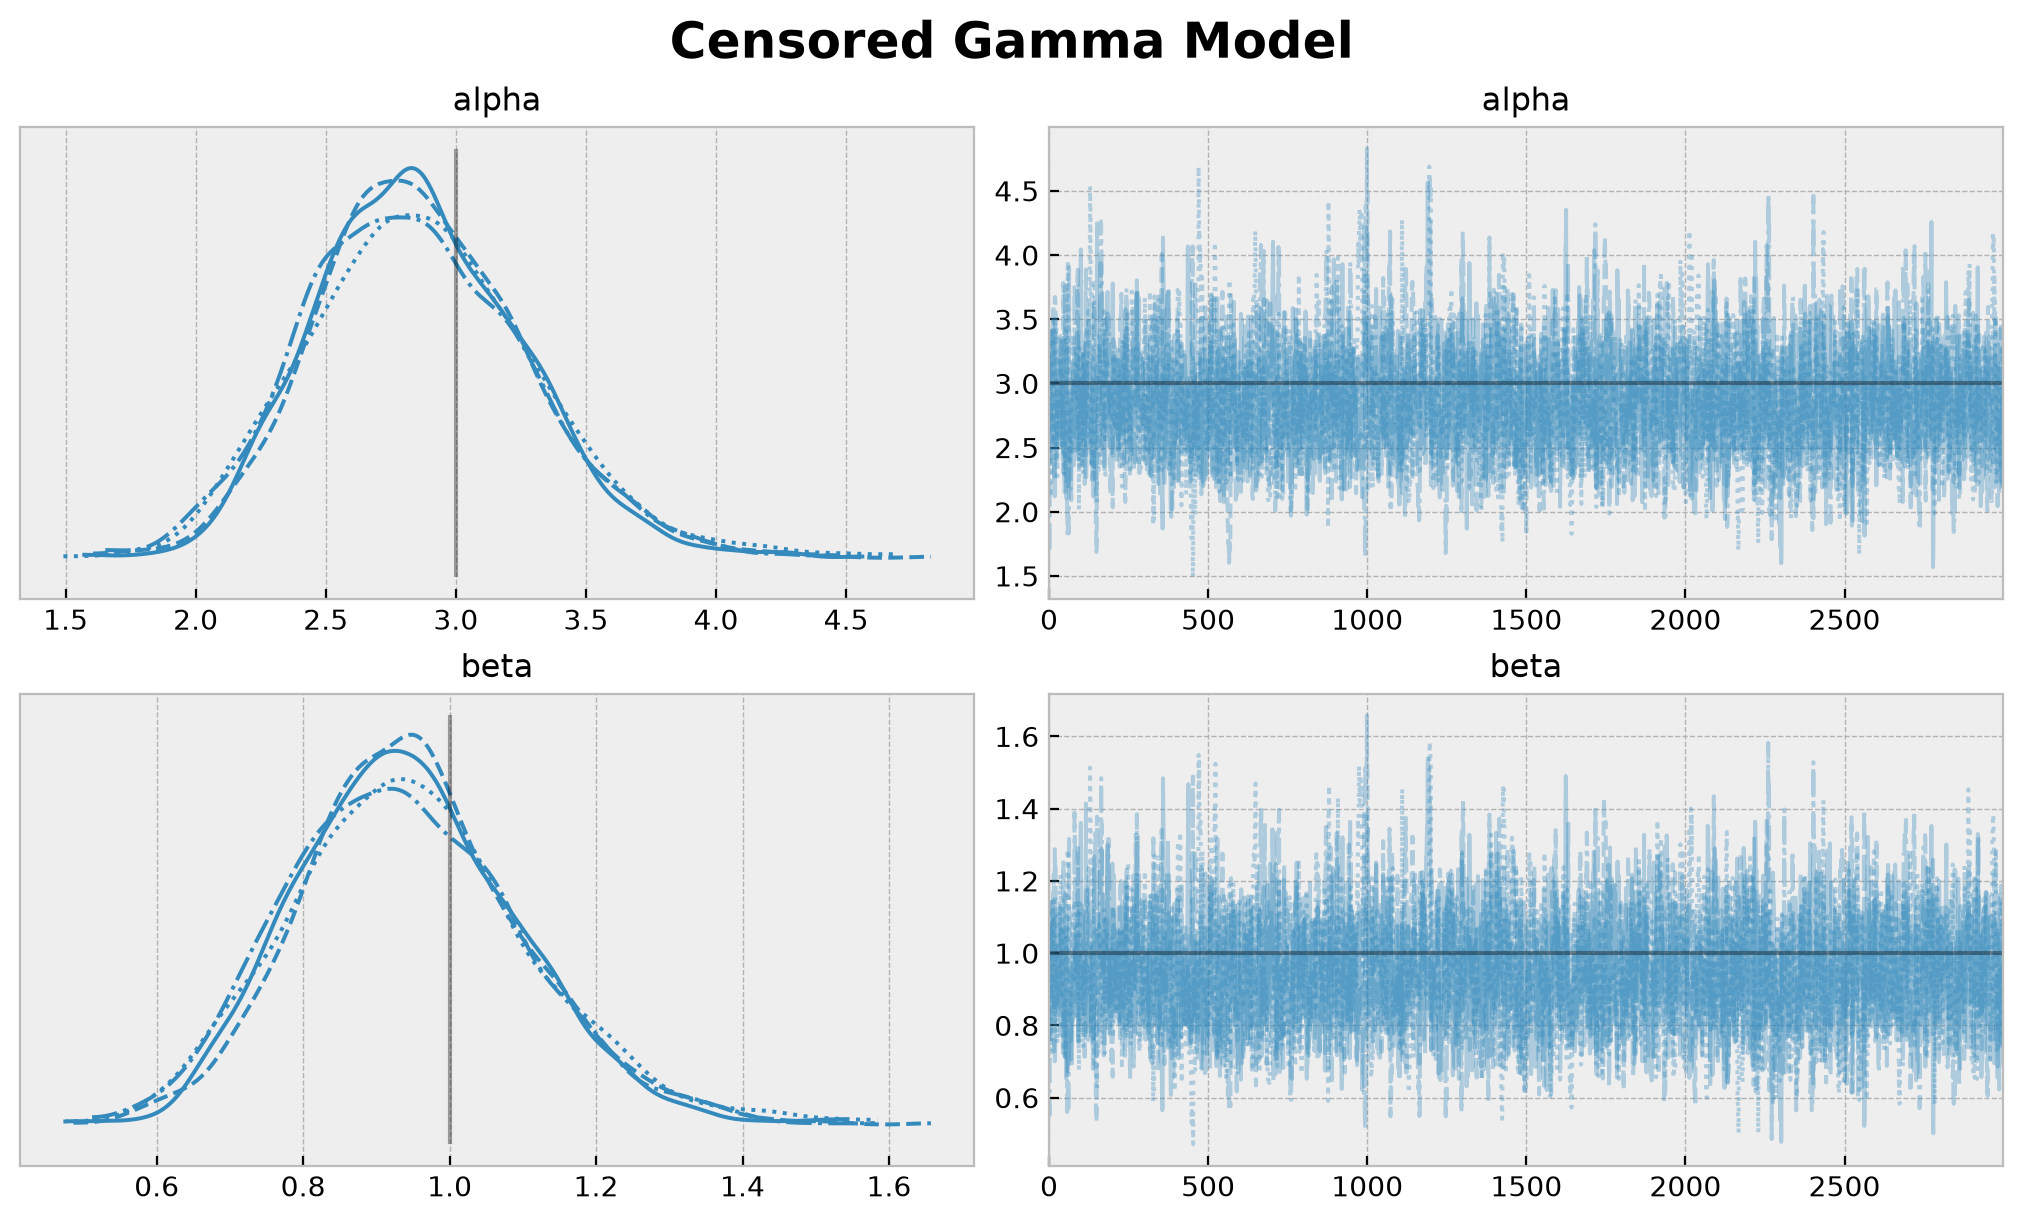

In [13]:
axes = az.plot_trace(
    data=censored_gamma_idata,
    compact=True,
    lines=[
        ("alpha", {}, censored_gamma_data_params.alpha),
        ("beta", {}, censored_gamma_data_params.beta),
    ],
    backend_kwargs={"figsize": (10, 6), "layout": "constrained"},
)
plt.gcf().suptitle("Censored Gamma Model", fontsize=18, fontweight="bold");

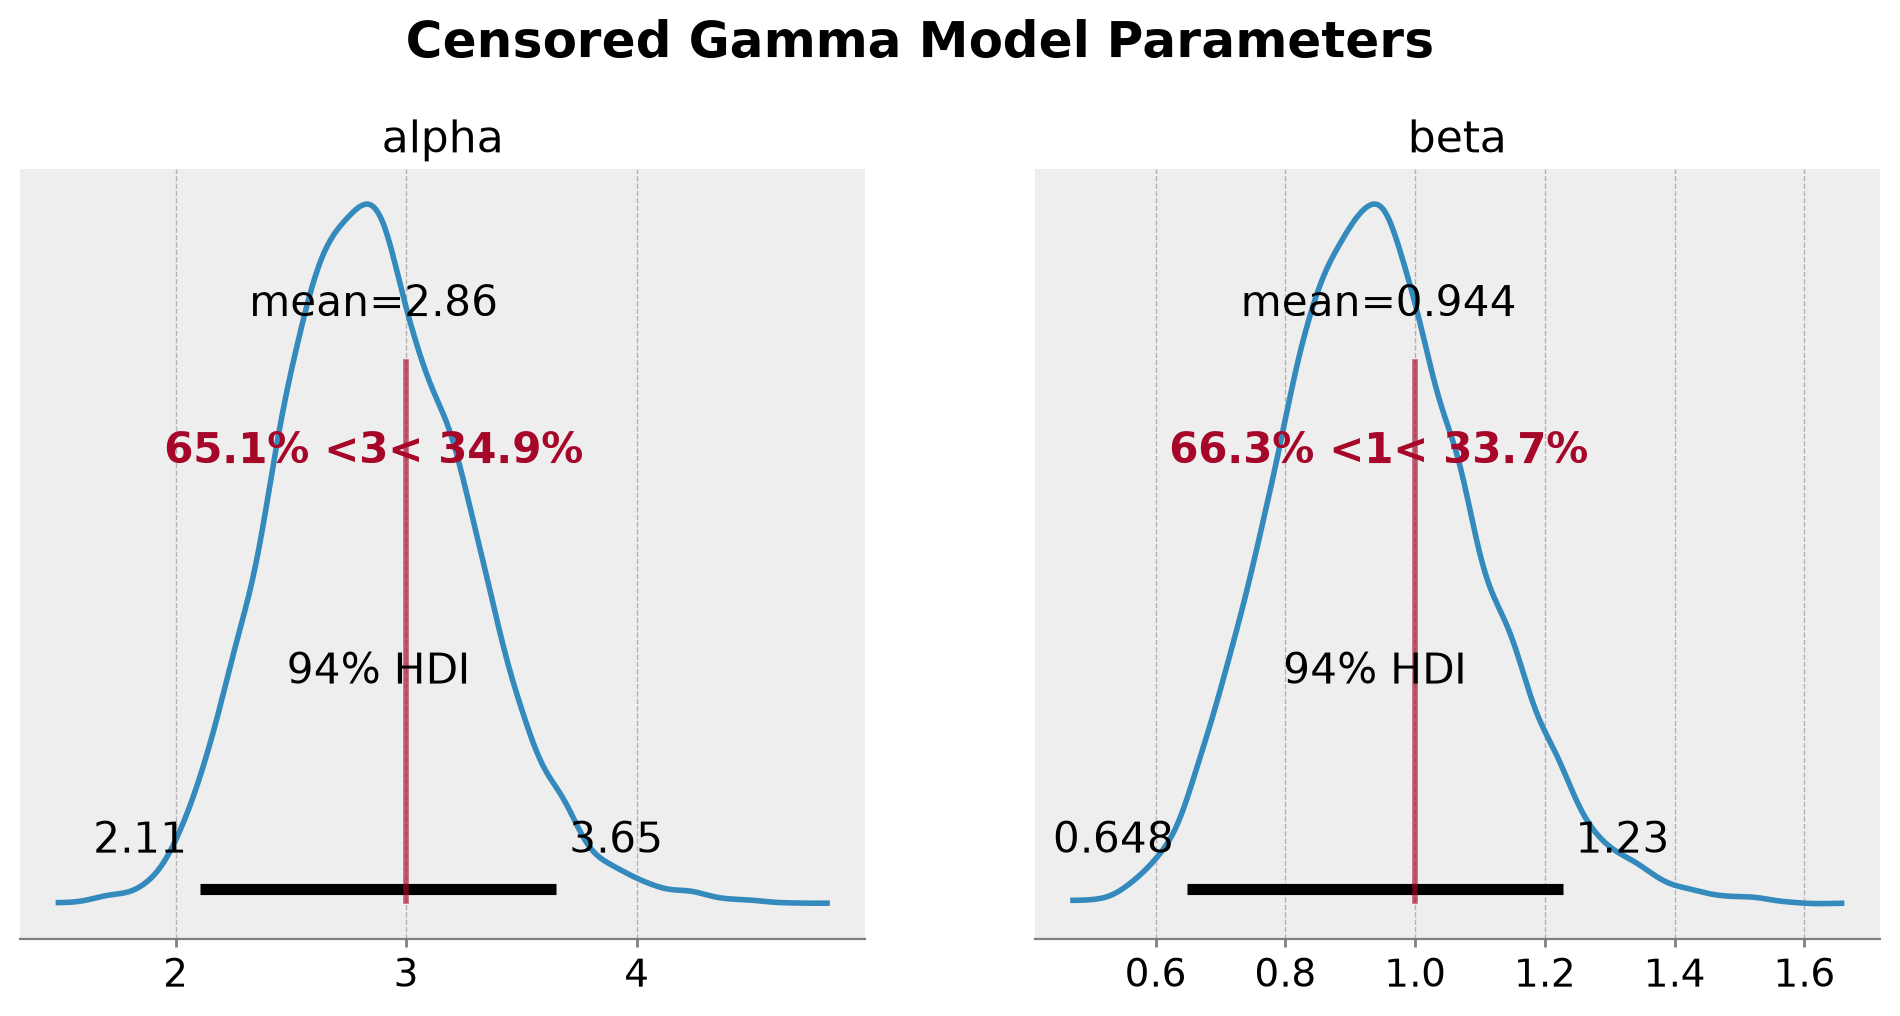

In [14]:
axes = az.plot_posterior(
    data=censored_gamma_idata,
    ref_val=[censored_gamma_data_params.alpha, censored_gamma_data_params.beta],
    round_to=3,
    figsize=(12, 5),
)
plt.gcf().suptitle(
    "Censored Gamma Model Parameters", fontsize=18, fontweight="bold", y=1.03
);

We clearly see that the true parameters are in correspond to the mean and mode of the posterior distribution. The censoring model is able to recover the true parameters.

As we did for the naive model, we visualize the inferred distribution and compare it with the true distribution from the data generating process.

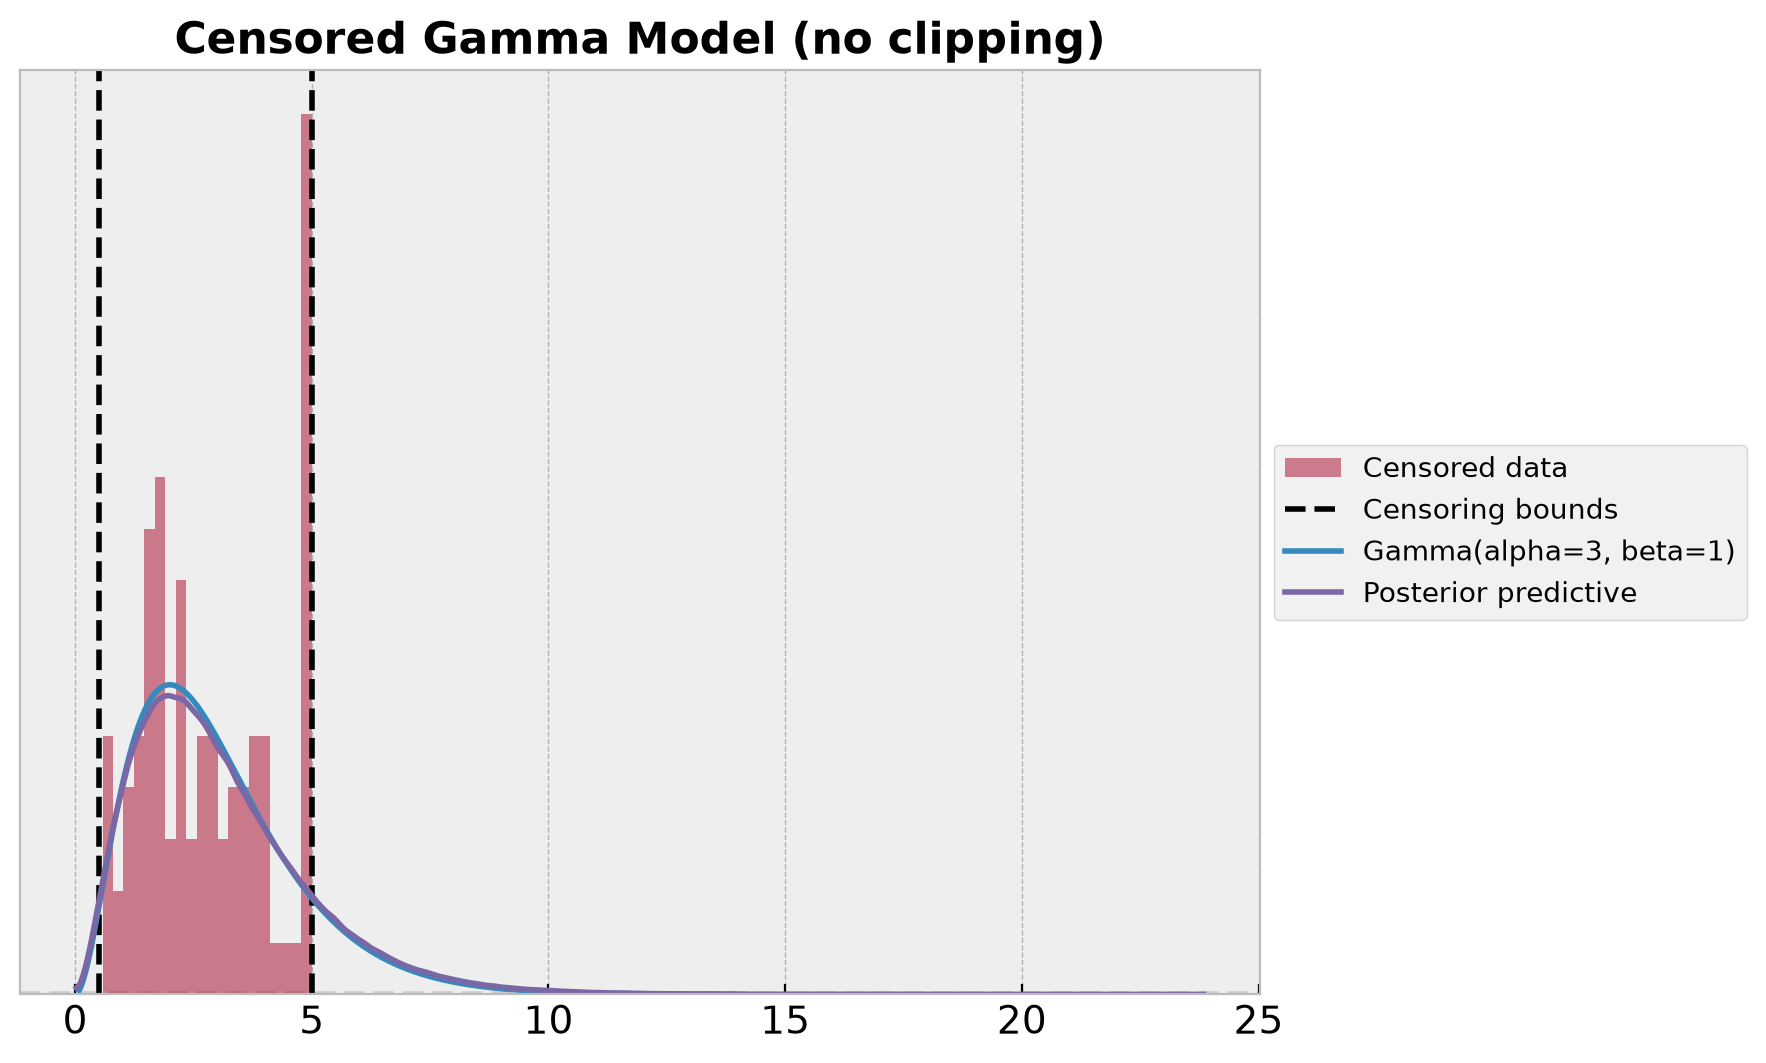

In [15]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_gamma_samples,
    bins=20,
    density=True,
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_gamma_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_gamma_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Gamma(
    alpha=censored_gamma_data_params.alpha, beta=censored_gamma_data_params.beta
).plot_pdf(color="C0", ax=ax)
az.plot_kde(
    censored_gamma_idata["posterior_predictive"]["obs"].to_numpy().flatten(),
    plot_kwargs={"color": "C2", "label": "Posterior predictive"},
    ax=ax,
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Censored Gamma Model (no clipping)", fontsize=16, fontweight="bold");

This looks much better than the naive model. However, there something wring as we are just sampling from the `obs` variable! We should not have posterior samples outside the censoring bounds. We can easily fix this by clipping the samples to the bounds.

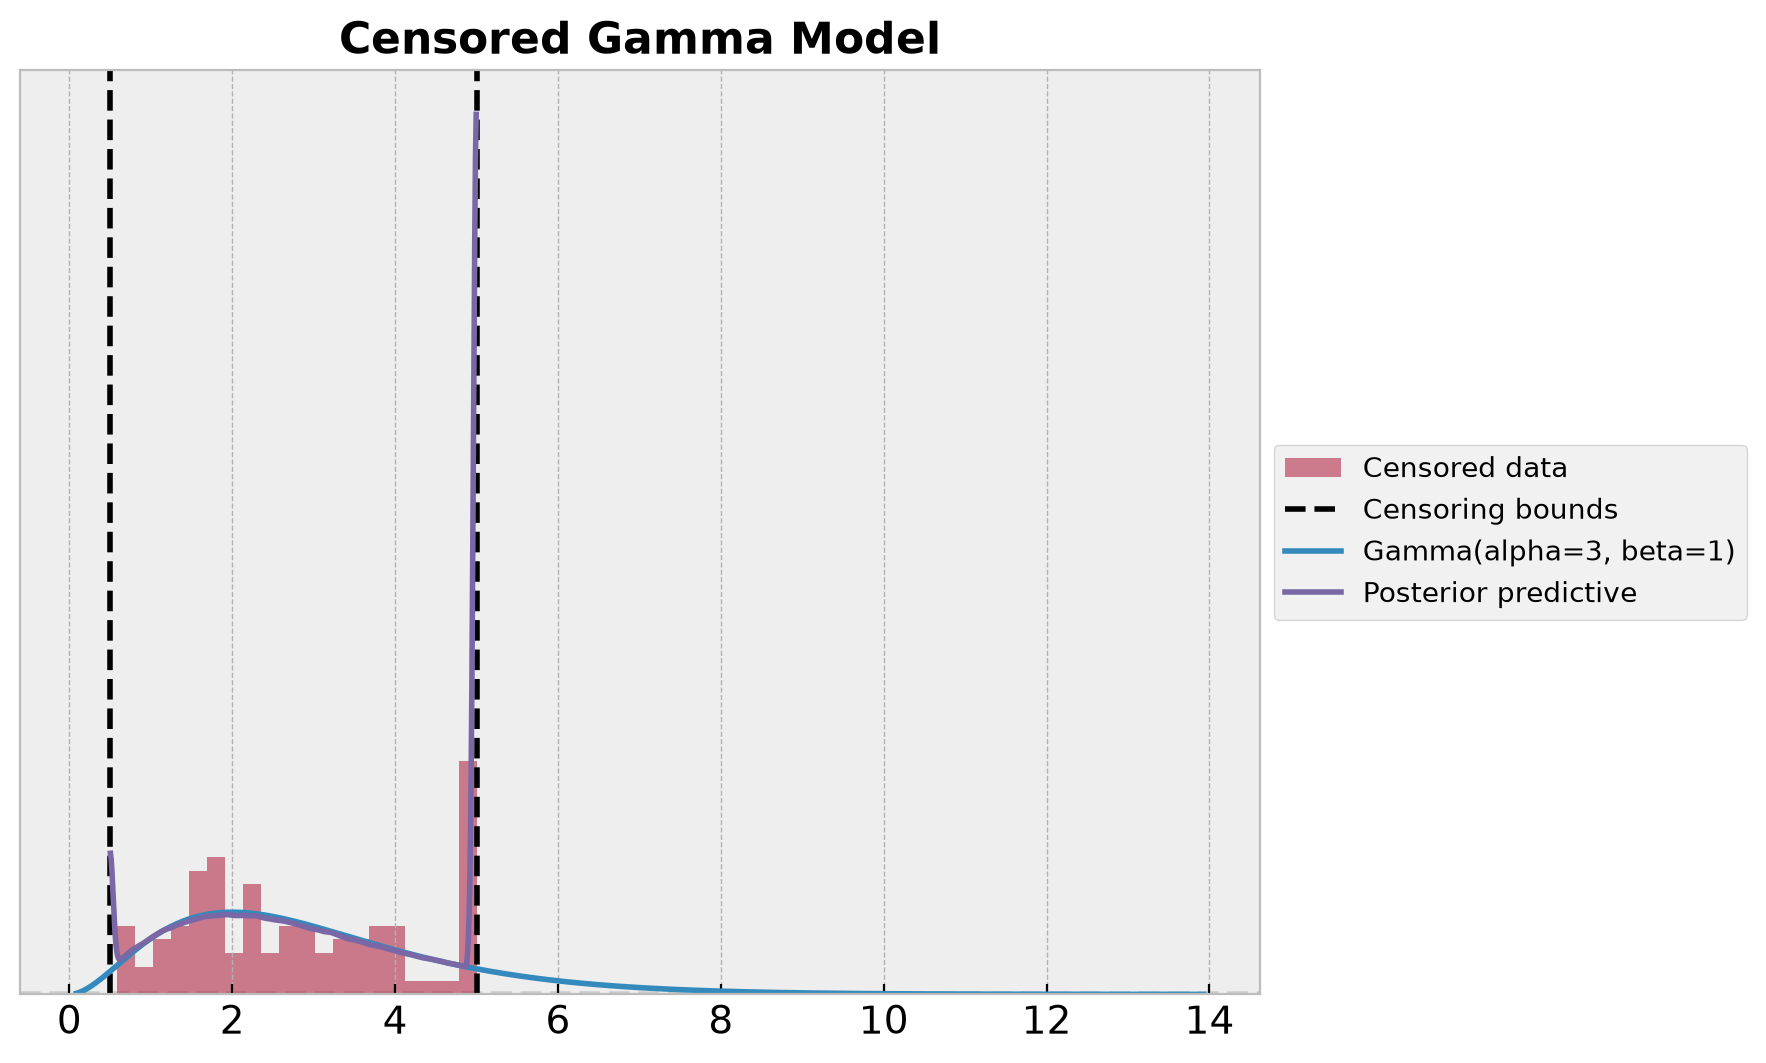

In [16]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_gamma_samples,
    bins=20,
    density=True,
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_gamma_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_gamma_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Gamma(
    alpha=censored_gamma_data_params.alpha, beta=censored_gamma_data_params.beta
).plot_pdf(color="C0", ax=ax)
az.plot_kde(
    censored_gamma_idata["posterior_predictive"]["obs"]
    .clip(min=censored_gamma_data_params.lower, max=censored_gamma_data_params.upper)
    .to_numpy()
    .flatten(),
    plot_kwargs={"color": "C2", "label": "Posterior predictive"},
    ax=ax,
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Censored Gamma Model", fontsize=16, fontweight="bold");

## Part II: Discrete Distribution

In this second part we do the same as in the first part but for a discrete distribution. Again, we assume that we have a dataset of observations $y$ that are censored from below and above at known thresholds. This time we assume the data follows a Poisson distribution (with parameter $\lambda$). We want to recover the true parameter $\lambda$. The censoring model has the same structure as in the continuous case, but there is a small detail in the upper bound. We need to add term to to the truncation probability to account for the probability of the upper bound. Specifically we need to add the probability of the upper bound using the PDF.

### Generate Censored Data

We generate data from a Poisson distribution and we *clip* the data to be between the thresholds `lower` and `upper`. We then plot the histogram of the data and the true Poisson distribution.

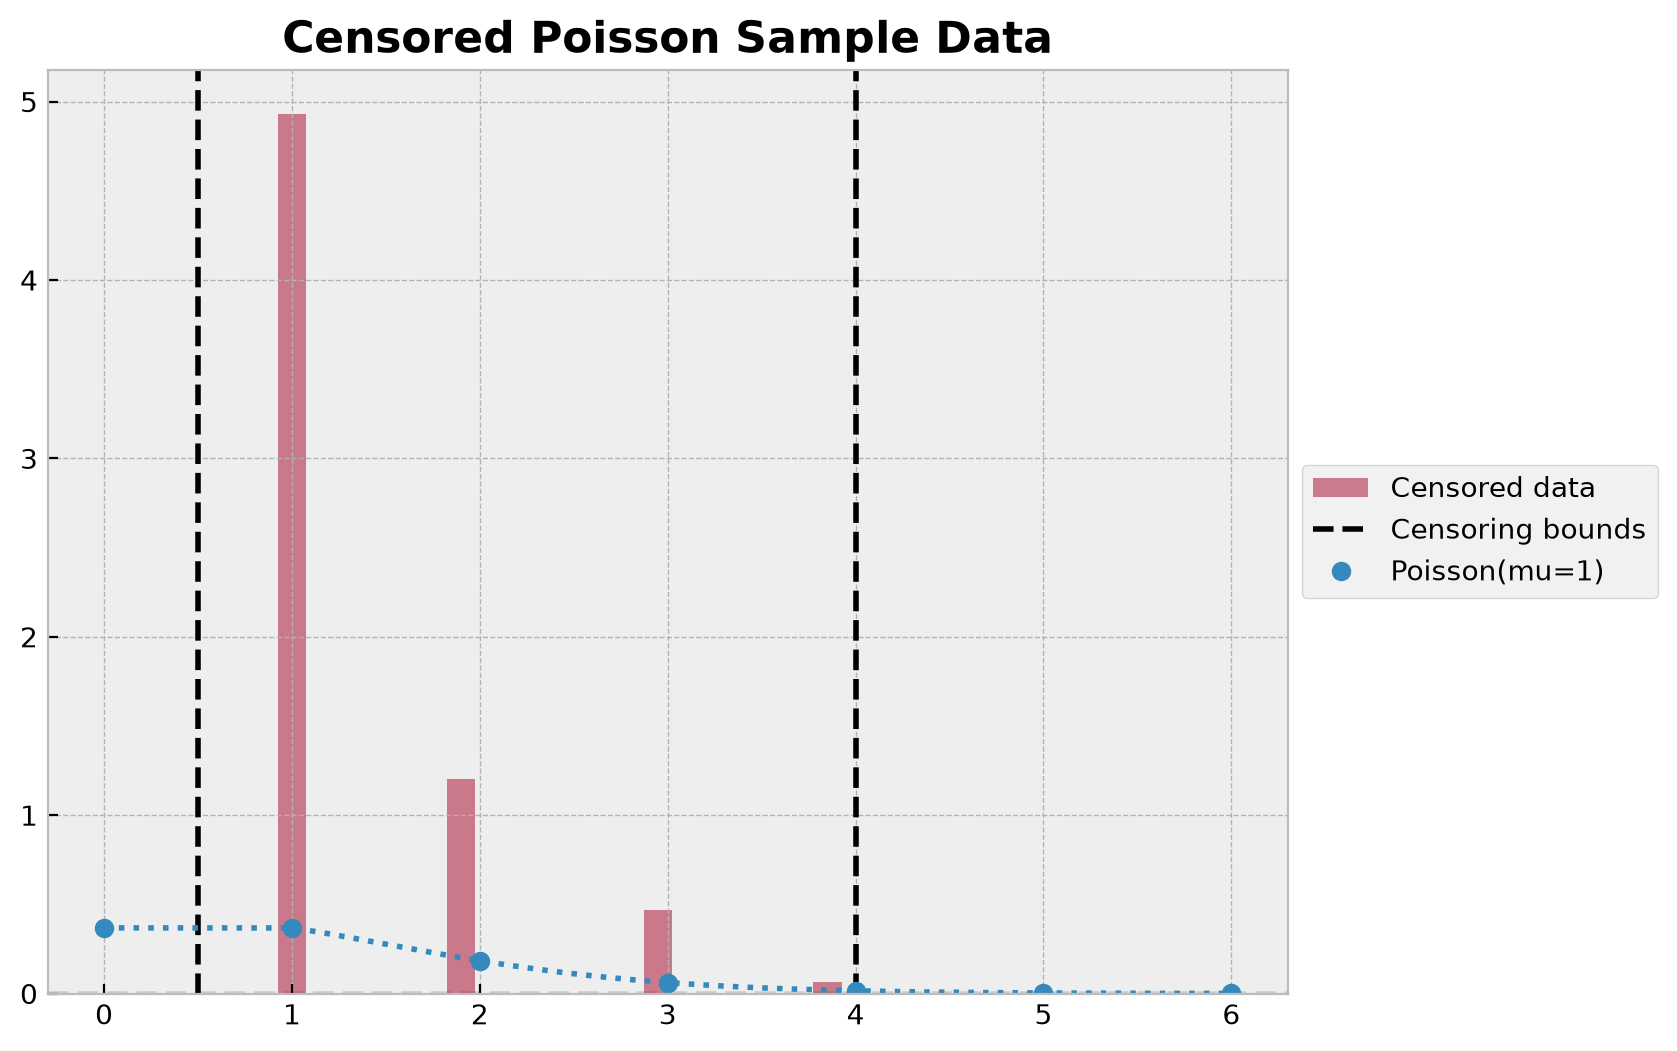

In [17]:
class CensoredPoissonDataParams(BaseModel):
    rate: float = Field(..., description="Rate parameter", gt=0)
    lower: float = Field(..., description="Lower censoring bound", gt=0)
    upper: float = Field(..., description="Upper censoring bound", gt=0)
    n: int = Field(..., description="Number of samples", gt=0)


def generate_censored_poisson_samples(
    rng_key: Array, params: CensoredPoissonDataParams
) -> Array:
    raw_samples = dist.Poisson(rate=params.rate).sample(rng_key, (params.n,))
    return jnp.clip(raw_samples, params.lower, params.upper)


censored_poisson_data_params = CensoredPoissonDataParams(
    rate=1, lower=1, upper=4, n=100
)
rng_key, rng_subkey = random.split(rng_key)
censored_poisson_samples = generate_censored_poisson_samples(
    rng_key=rng_subkey, params=censored_poisson_data_params
)

fig, ax = plt.subplots()
_ = ax.hist(
    censored_poisson_samples,
    bins=20,
    density=True,
    color="C1",
    alpha=0.5,
    label="Censored data",
    align="left",
)
ax.axvline(censored_gamma_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_poisson_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Poisson(mu=censored_poisson_data_params.rate).plot_pdf(color="C0", ax=ax)
ax.set_title("Censored Poisson Sample Data", fontsize=16, fontweight="bold");

### Naive Model

Just as in the continuous case, we start with a naive model that does not take into account the censoring component. We simply use a Poisson distribution with parameter $\lambda$ to model the data.

In [18]:
def poisson_model(y: Array) -> None:
    rate = numpyro.sample("rate", dist.Exponential(1.0))
    numpyro.sample("obs", dist.Poisson(rate), obs=y)


poisson_kernel = NUTS(poisson_model)
poisson_mcmc = MCMC(
    poisson_kernel,
    num_warmup=inference_params.num_warmup,
    num_samples=inference_params.num_samples,
    num_chains=inference_params.num_chains,
)
rng_key, rng_subkey = random.split(rng_key)
poisson_mcmc.run(rng_key, y=censored_poisson_samples)

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 1:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 2:   0%|          | 0/5000 [00:00<?, ?it/s]

In [19]:
poisson_predictive = Predictive(
    model=poisson_model, posterior_samples=poisson_mcmc.get_samples()
)
rng_key, rng_subkey = random.split(rng_key)
poisson_posterior_predictive = poisson_predictive(rng_subkey, y=None)

poisson_idata = az.from_numpyro(posterior=poisson_mcmc)
poisson_idata.extend(az.from_numpyro(posterior_predictive=poisson_posterior_predictive))

Running chain 0:  65%|██████▌   | 3250/5000 [00:00<00:00, 32045.29it/s]

Running chain 2:  60%|██████    | 3000/5000 [00:00<00:00, 29431.92it/s]

Running chain 3:  65%|██████▌   | 3250/5000 [00:00<00:00, 31698.04it/s]

Running chain 1:  65%|██████▌   | 3250/5000 [00:00<00:00, 30859.18it/s]

Running chain 0: 100%|██████████| 5000/5000 [00:00<00:00, 8986.14it/s] 


Running chain 3: 100%|██████████| 5000/5000 [00:00<00:00, 8973.39it/s] 


Running chain 2: 100%|██████████| 5000/5000 [00:00<00:00, 8912.97it/s] 


Running chain 1: 100%|██████████| 5000/5000 [00:00<00:00, 8885.09it/s] 

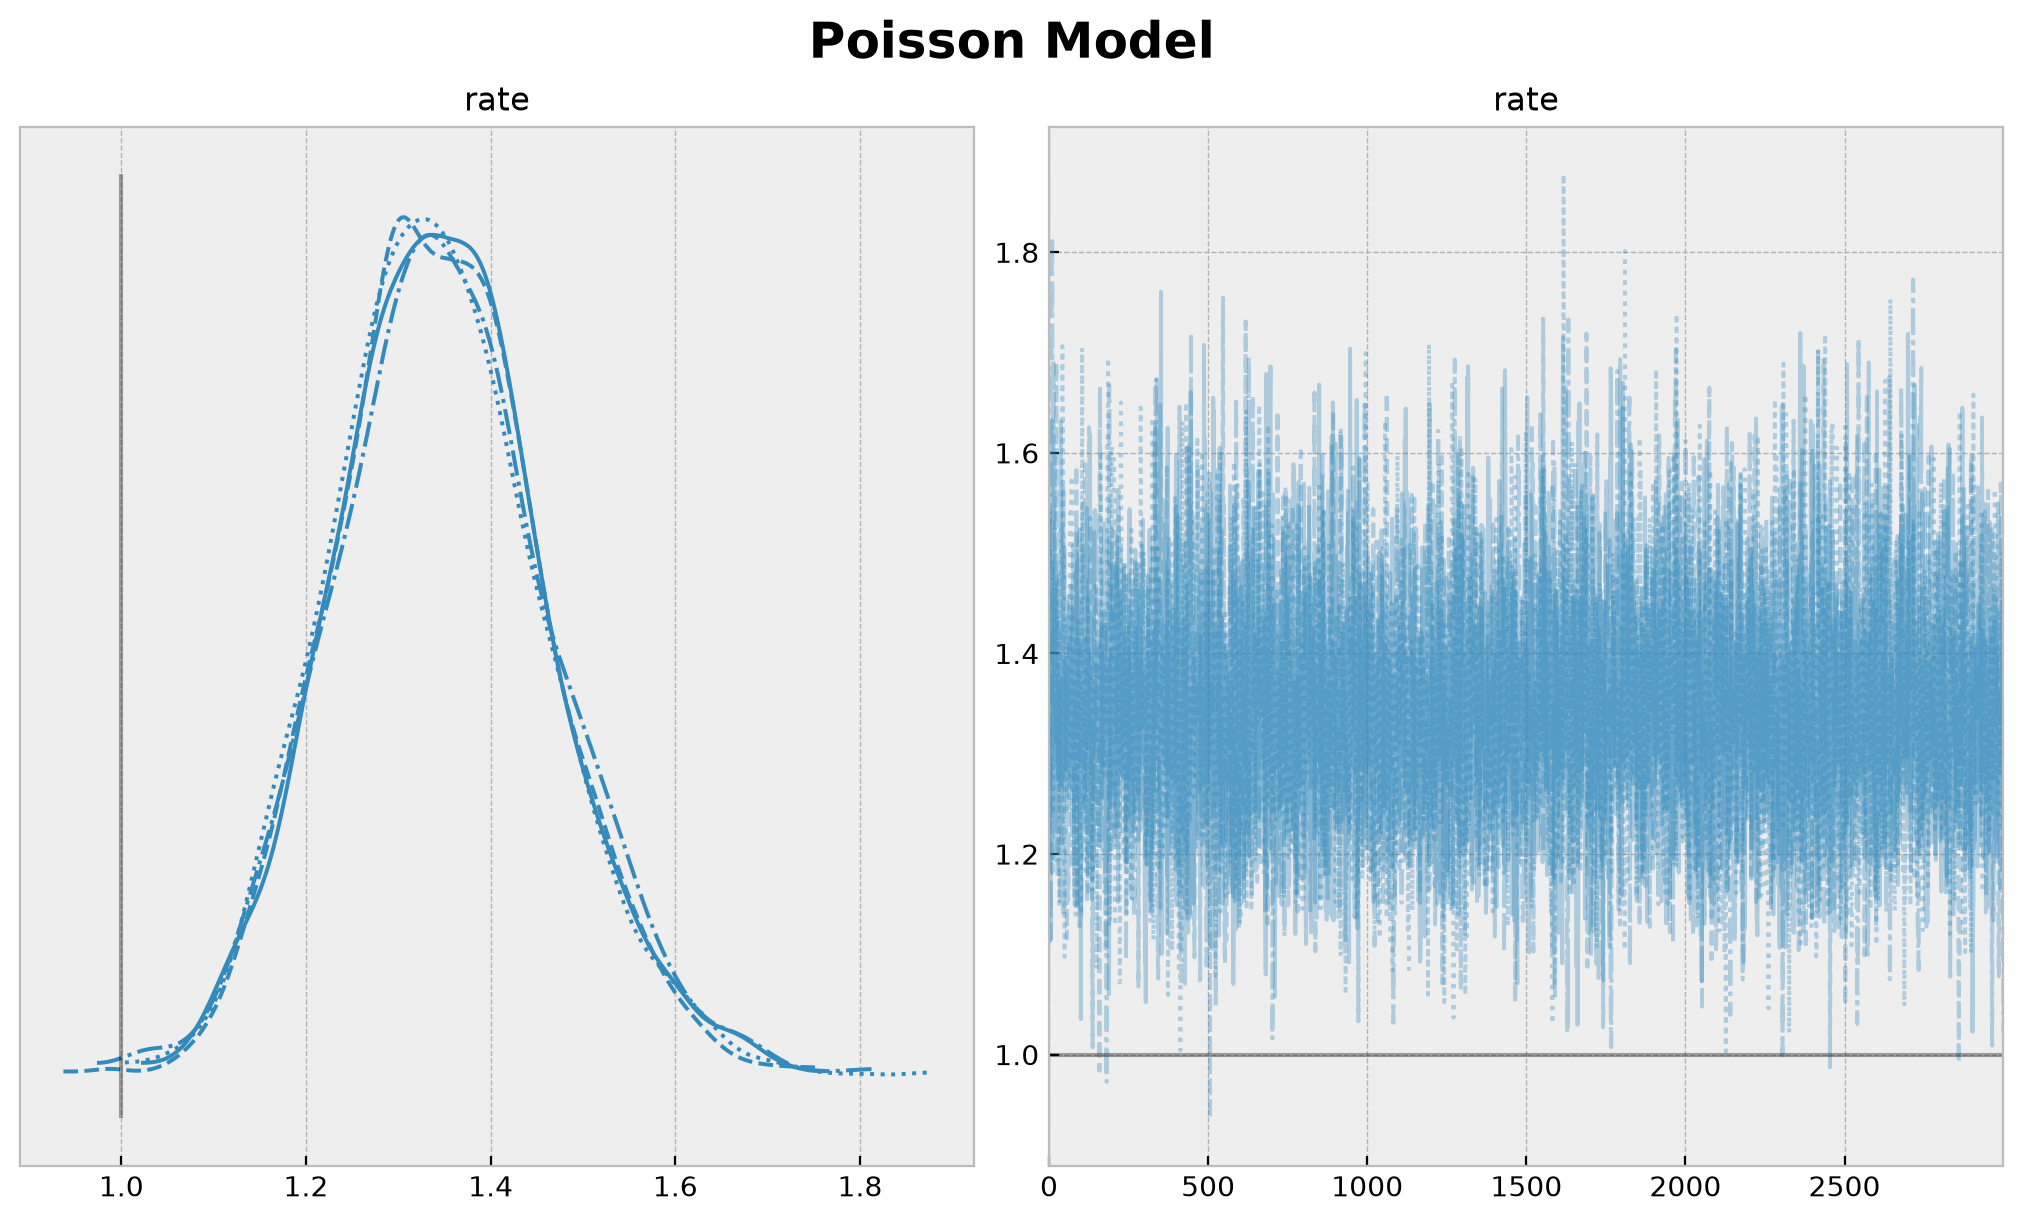

In [20]:
axes = az.plot_trace(
    data=poisson_idata,
    compact=True,
    lines=[("rate", {}, censored_poisson_data_params.rate)],
    backend_kwargs={"figsize": (10, 6), "layout": "constrained"},
)
plt.gcf().suptitle("Poisson Model", fontsize=18, fontweight="bold");

findfont: Failed to find font weight semibold, now using 700.


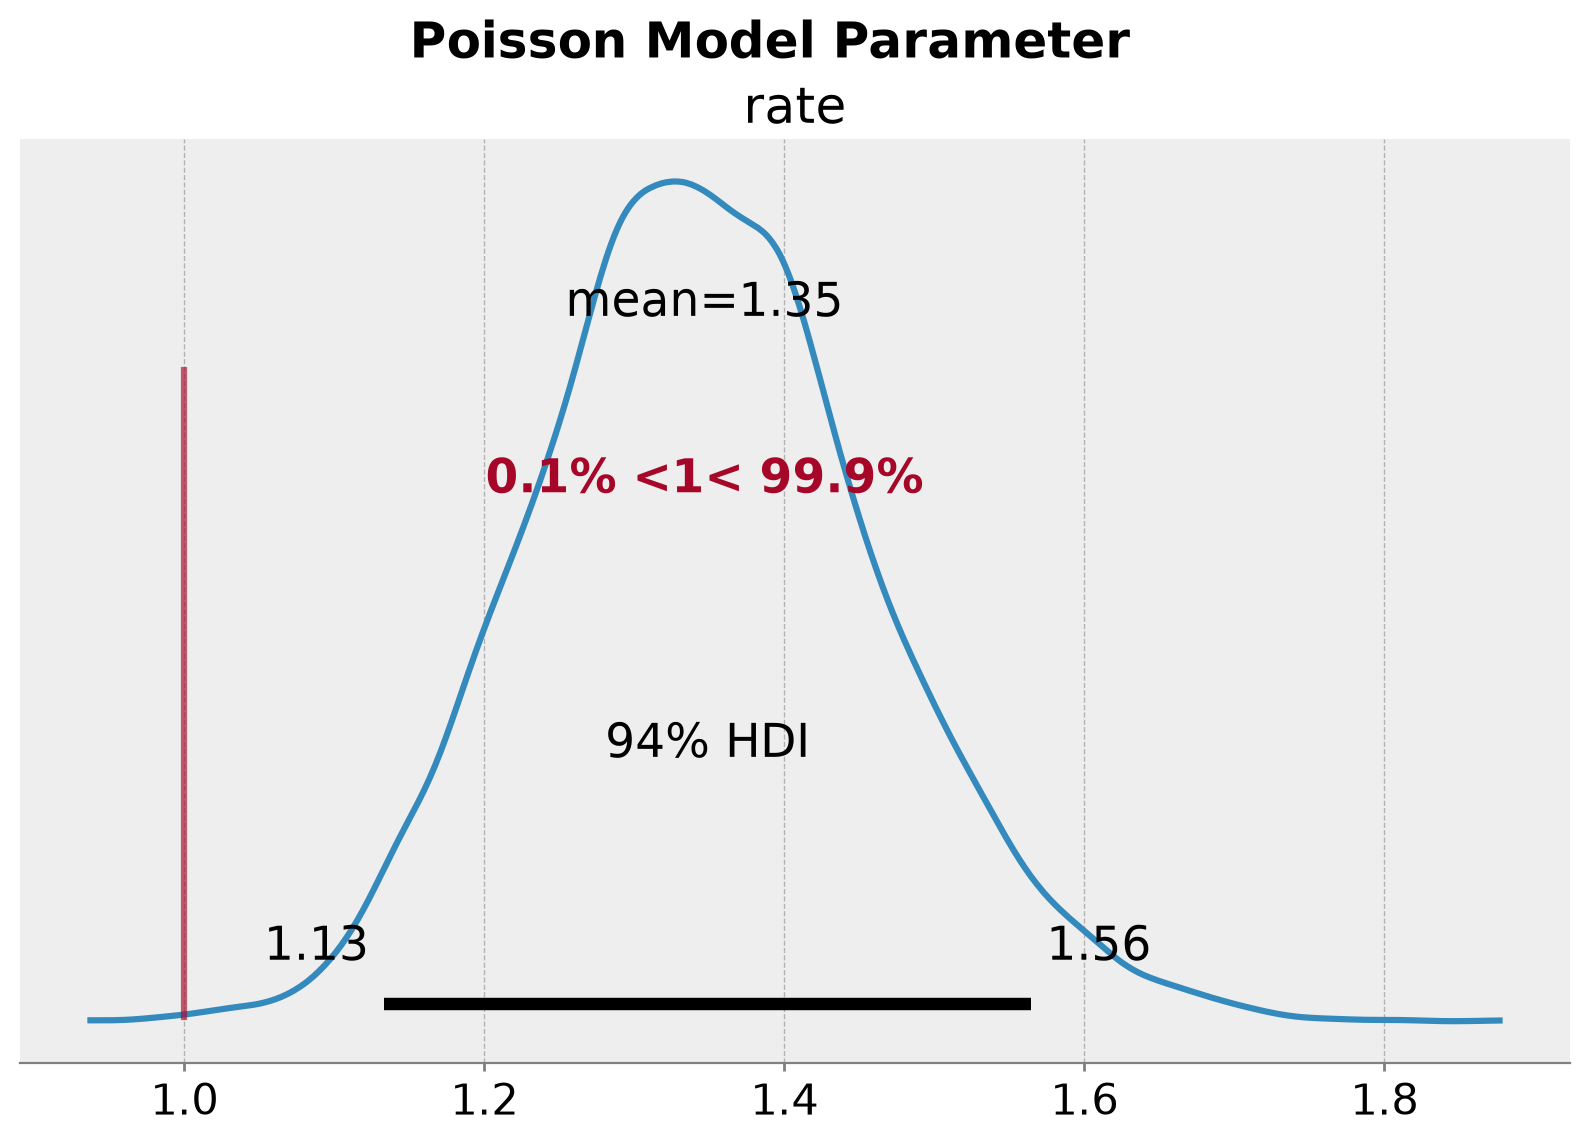

In [21]:
axes = az.plot_posterior(
    data=poisson_idata,
    ref_val=[censored_poisson_data_params.rate],
    round_to=3,
    figsize=(10, 6),
)
plt.gcf().suptitle("Poisson Model Parameter", fontsize=18, fontweight="bold");

We clearly see a bias in the estimation of the parameter. The true value of the rate parameter $\lambda$ is not even in the $94\%$ HDI.

We can also take a look into the posterior predictive distribution.

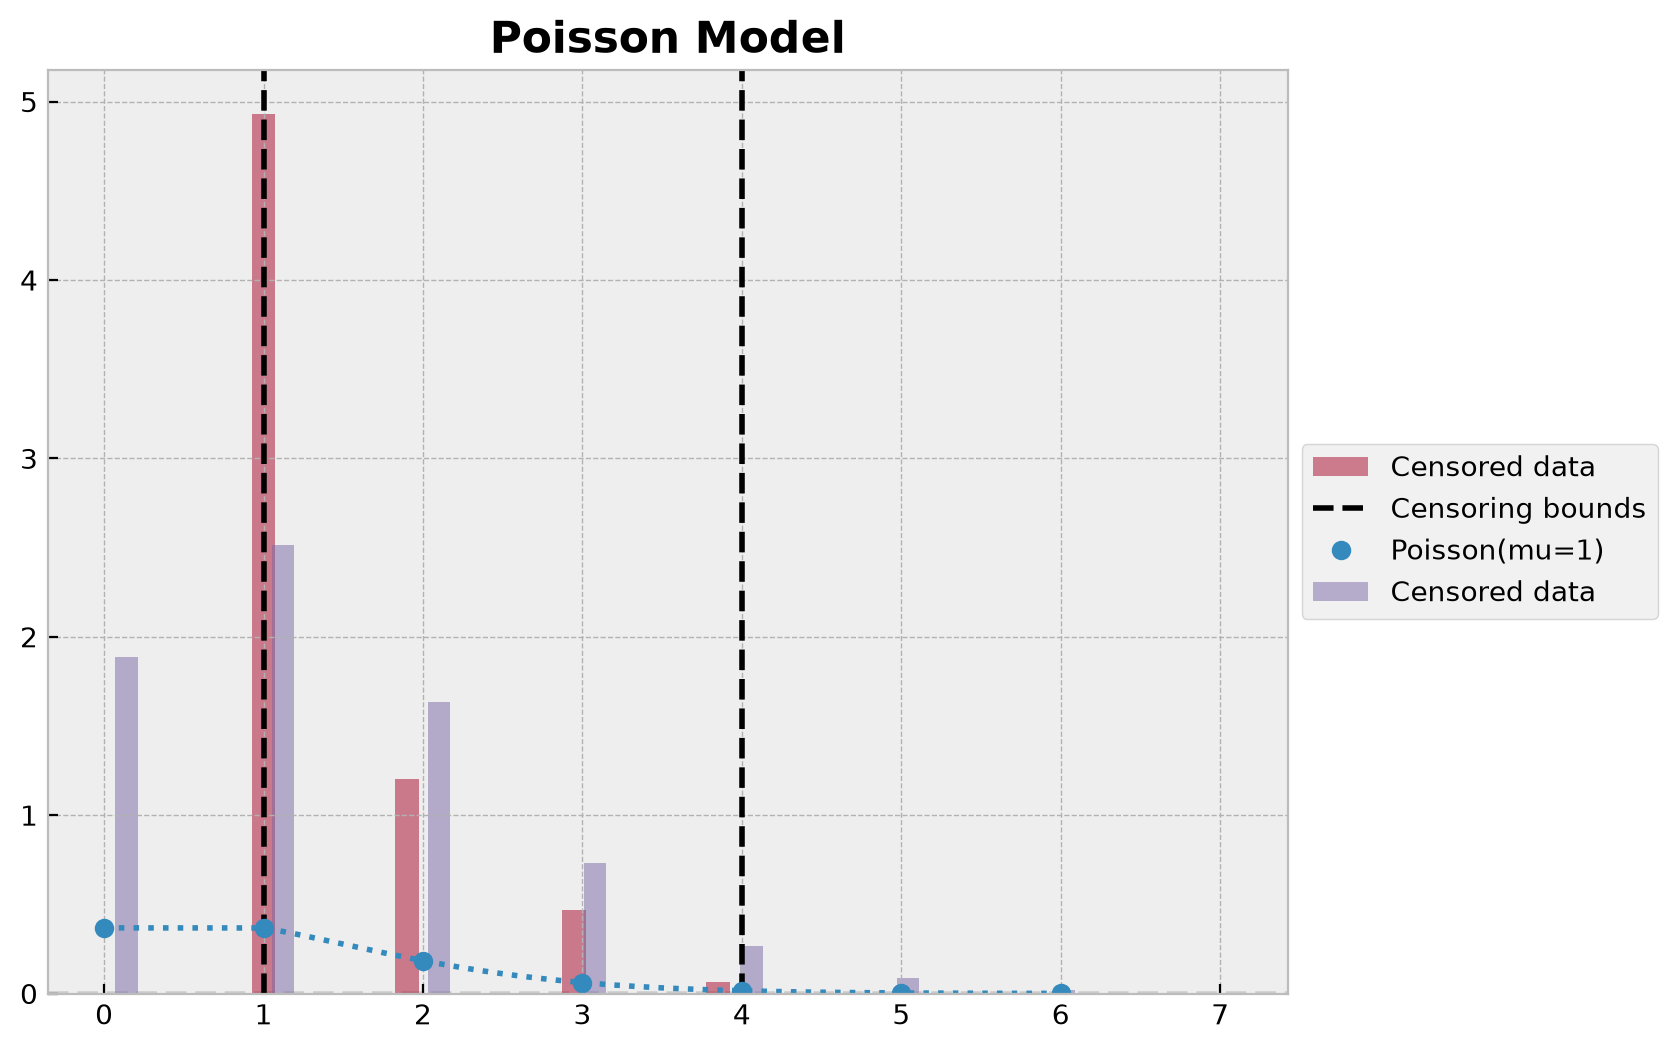

In [22]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_poisson_samples,
    bins=20,
    density=True,
    align="left",
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_poisson_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_poisson_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Poisson(mu=censored_poisson_data_params.rate).plot_pdf(color="C0", ax=ax)
_ = ax.hist(
    poisson_idata["posterior_predictive"]["obs"].to_numpy().flatten(),
    bins=50,
    density=True,
    align="right",
    color="C2",
    alpha=0.5,
    label="Censored data",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Poisson Model", fontsize=16, fontweight="bold");

### Censored Poisson Model

Now we work out the censored model. As before, we need to compute the censoring indicators:

In [23]:
left_censored, right_censored = get_censoring_indicators(
    y=censored_poisson_samples,
    lower=censored_poisson_data_params.lower,
    upper=censored_poisson_data_params.upper,
)

Now, finally regarding the detail about the upper censoring component. 

- We want to consider the **closed** interval $P(lower \leq y \leq upper)$.
- For the upper interval we use $1 - CDF(upper) = 1- P(y \leq upper) = P(y > upper)$, but we actually need $P(y \geq upper)$. 
- Hence we need to add $P(y= upper)$ in the upper truncation probability.
- Observe that this discussion is irrelevant for the *continuous* case as the probability of a single point is zero so $P(y > upper) = P(y \geq upper)$.

With `IntervalCensoredDistribution` the right-censored contribution is $1 - CDF(lower\_bound) = P(y > lower\_bound)$, so for a discrete distribution we simply pass $upper - 1$ as the lower bound of the right-censored rows: $P(y > upper - 1) = P(y \geq upper)$, which is exactly the correction above.

The implementation of the model should be clearer now.

In [24]:
def censored_poisson_model(
    y: Array, left_censored: Array, right_censored: Array
) -> None:
    rate = numpyro.sample("rate", dist.Exponential(1.0))

    distribution = dist.Poisson(rate)
    censored_distribution = dist.IntervalCensoredDistribution(
        base_dist=distribution,
        left_censored=left_censored,
        right_censored=right_censored,
    )
    if y is not None:
        lower_bound = jnp.where(right_censored, y - 1, y)
        obs = jnp.stack([lower_bound, y], axis=-1)
    else:
        obs = None
    numpyro.sample("obs", censored_distribution, obs=obs)

**Remark:** The need for this correction in the discrete case was an important detail pointed out by [Kyle Caron](https://kylejcaron.github.io/) in his blog post ["Modeling Anything With First Principles: Demand under extreme stockouts"](https://kylejcaron.github.io/posts/censored_demand/2024-02-06-censored-demand.html). With `IntervalCensoredDistribution` it boils down to shifting the lower bound of the right-censored rows by one.

We proceed to fit the model and compare the results with the true parameter.

In [25]:
censored_poisson_kernel = NUTS(censored_poisson_model)
censored_poisson_mcmc = MCMC(
    censored_poisson_kernel,
    num_warmup=inference_params.num_warmup,
    num_samples=inference_params.num_samples,
    num_chains=inference_params.num_chains,
)
rng_key, rng_subkey = random.split(rng_key)
censored_poisson_mcmc.run(
    rng_key,
    y=censored_poisson_samples,
    left_censored=left_censored,
    right_censored=right_censored,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 1:   0%|          | 0/5000 [00:00<?, ?it/s]

Running chain 2:   0%|          | 0/5000 [00:00<?, ?it/s]

In [26]:
censored_poisson_predictive = Predictive(
    model=censored_poisson_model,
    posterior_samples=censored_poisson_mcmc.get_samples(),
    return_sites=["obs"],
)
rng_key, rng_subkey = random.split(rng_key)
censored_poisson_posterior_predictive = censored_poisson_predictive(
    rng_subkey,
    y=None,
    left_censored=left_censored,
    right_censored=right_censored,
)

censored_poisson_idata = az.from_numpyro(posterior=censored_poisson_mcmc)
censored_poisson_idata.extend(
    az.from_numpyro(posterior_predictive=censored_poisson_posterior_predictive)
)

Running chain 1:  40%|████      | 2000/5000 [00:00<00:00, 19802.62it/s]

Running chain 0:  40%|████      | 2000/5000 [00:00<00:00, 19602.85it/s]

Running chain 2:  40%|████      | 2000/5000 [00:00<00:00, 19719.81it/s]

Running chain 3:  40%|████      | 2000/5000 [00:00<00:00, 19682.51it/s]

Running chain 0:  95%|█████████▌| 4750/5000 [00:00<00:00, 24109.38it/s]

...

Running chain 1: 100%|██████████| 5000/5000 [00:00<00:00, 23801.84it/s]

Running chain 0: 100%|██████████| 5000/5000 [00:00<00:00, 5219.97it/s] 


Running chain 1: 100%|██████████| 5000/5000 [00:00<00:00, 5221.01it/s] 


Running chain 3: 100%|██████████| 5000/5000 [00:00<00:00, 5199.74it/s] 


Running chain 2: 100%|██████████| 5000/5000 [00:00<00:00, 5132.91it/s] 

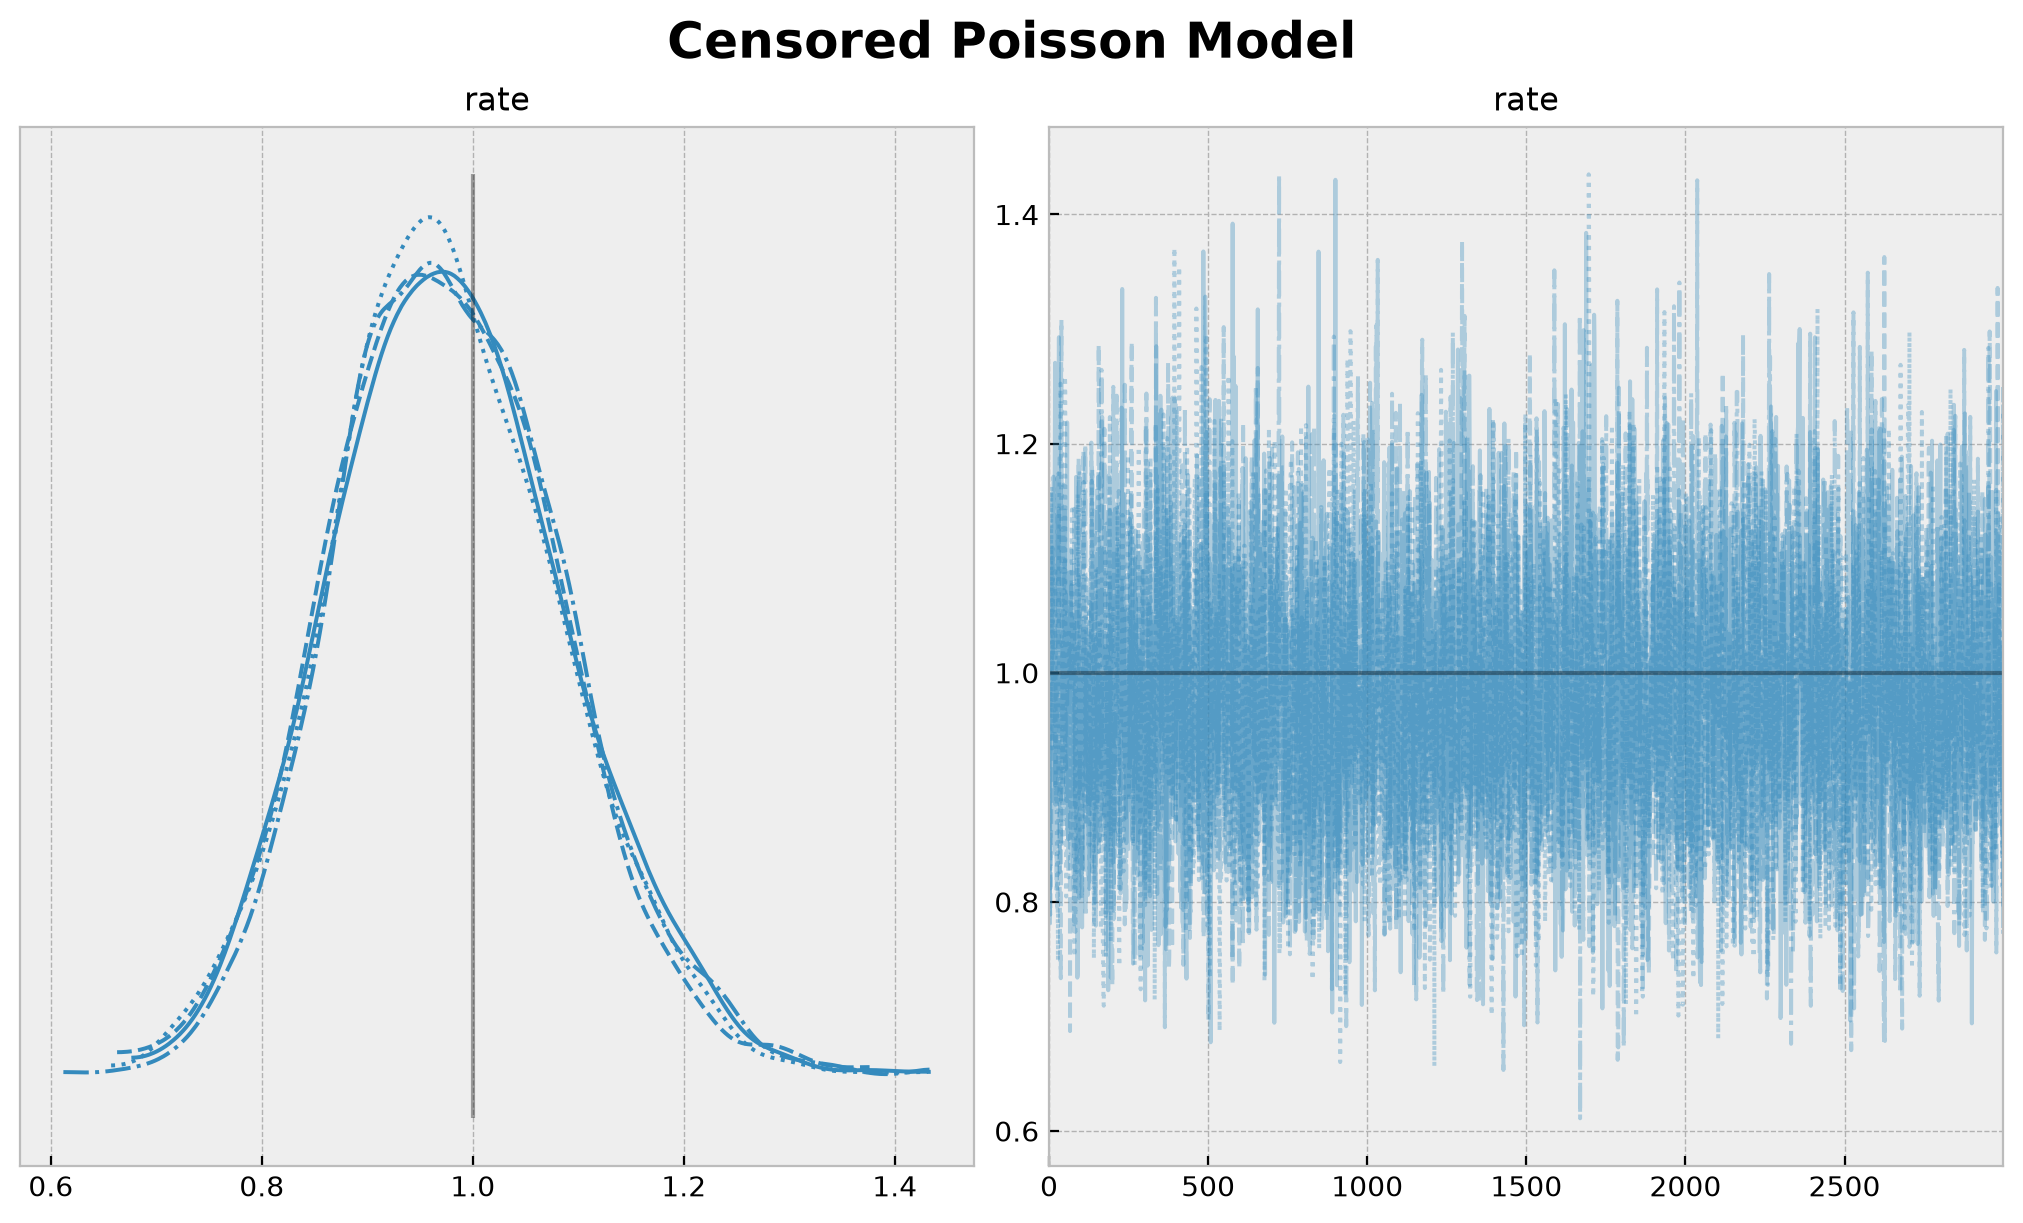

In [27]:
axes = az.plot_trace(
    data=censored_poisson_idata,
    compact=True,
    lines=[("rate", {}, censored_poisson_data_params.rate)],
    backend_kwargs={"figsize": (10, 6), "layout": "constrained"},
)
plt.gcf().suptitle("Censored Poisson Model", fontsize=18, fontweight="bold");

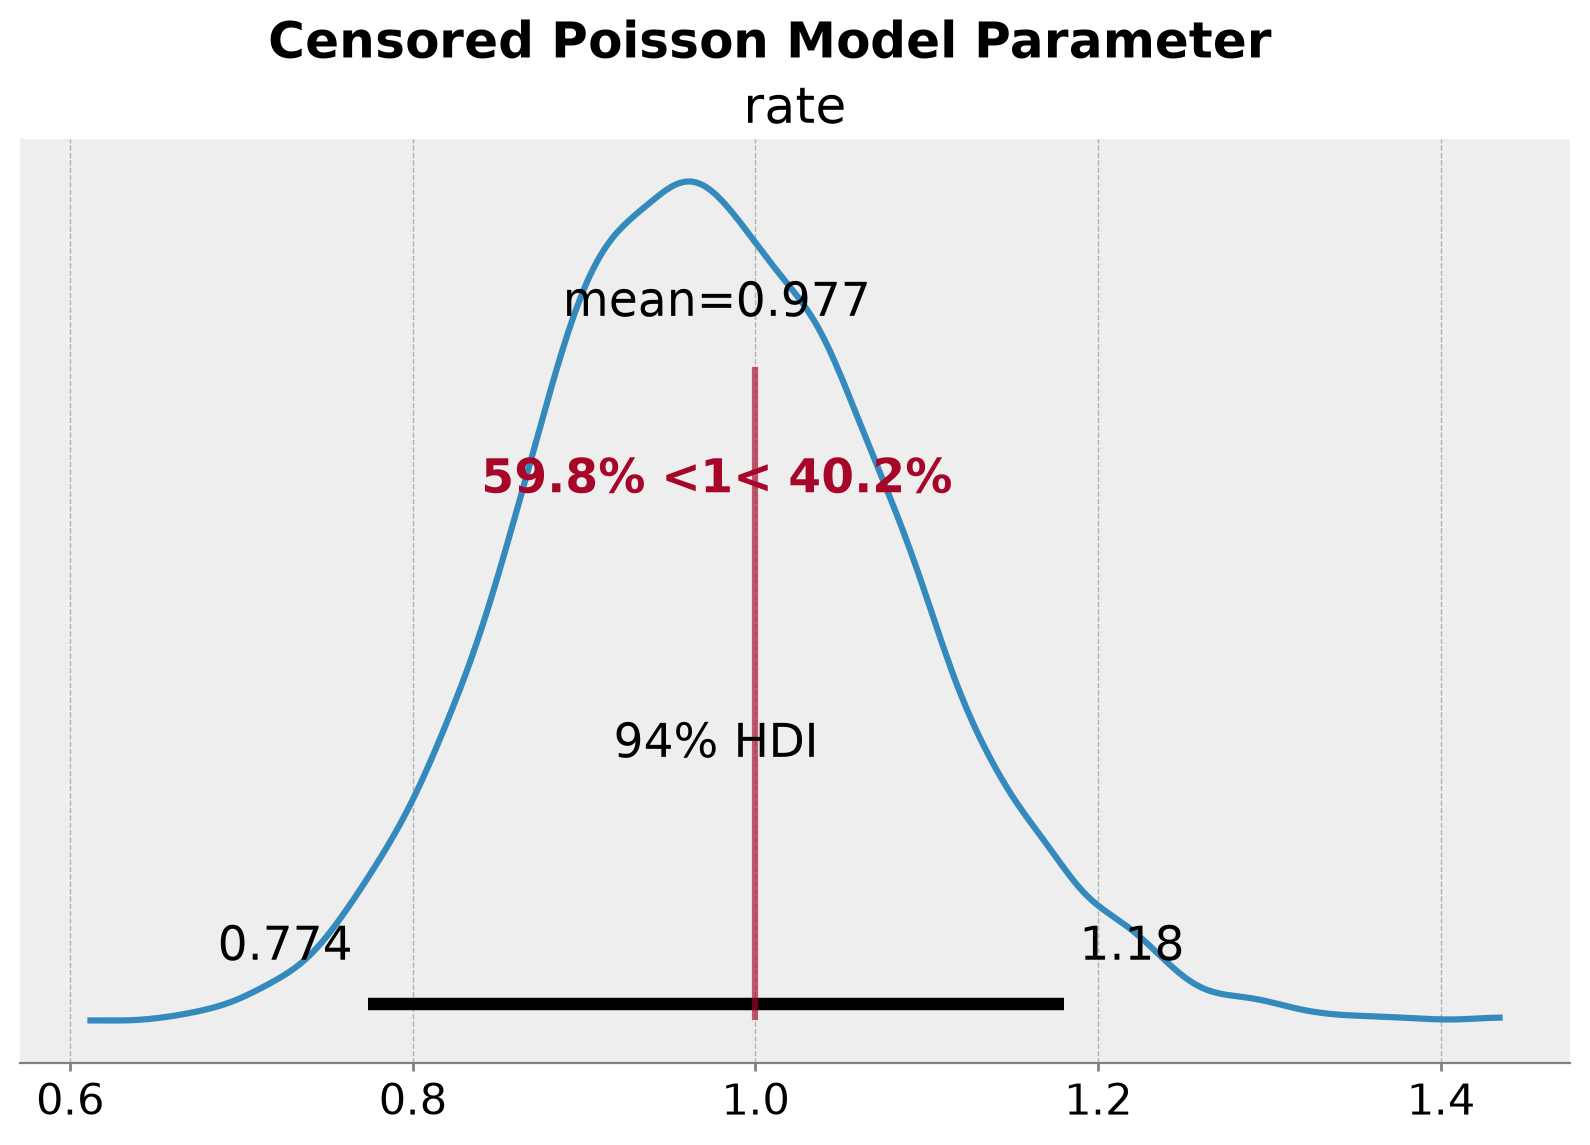

In [28]:
axes = az.plot_posterior(
    data=censored_poisson_idata,
    ref_val=[censored_poisson_data_params.rate],
    round_to=3,
    figsize=(10, 6),
)
plt.gcf().suptitle("Censored Poisson Model Parameter", fontsize=18, fontweight="bold");

We see that we have recovered the true value of the rate parameter $\lambda = 1$.

Here is the posterior predictive distribution:

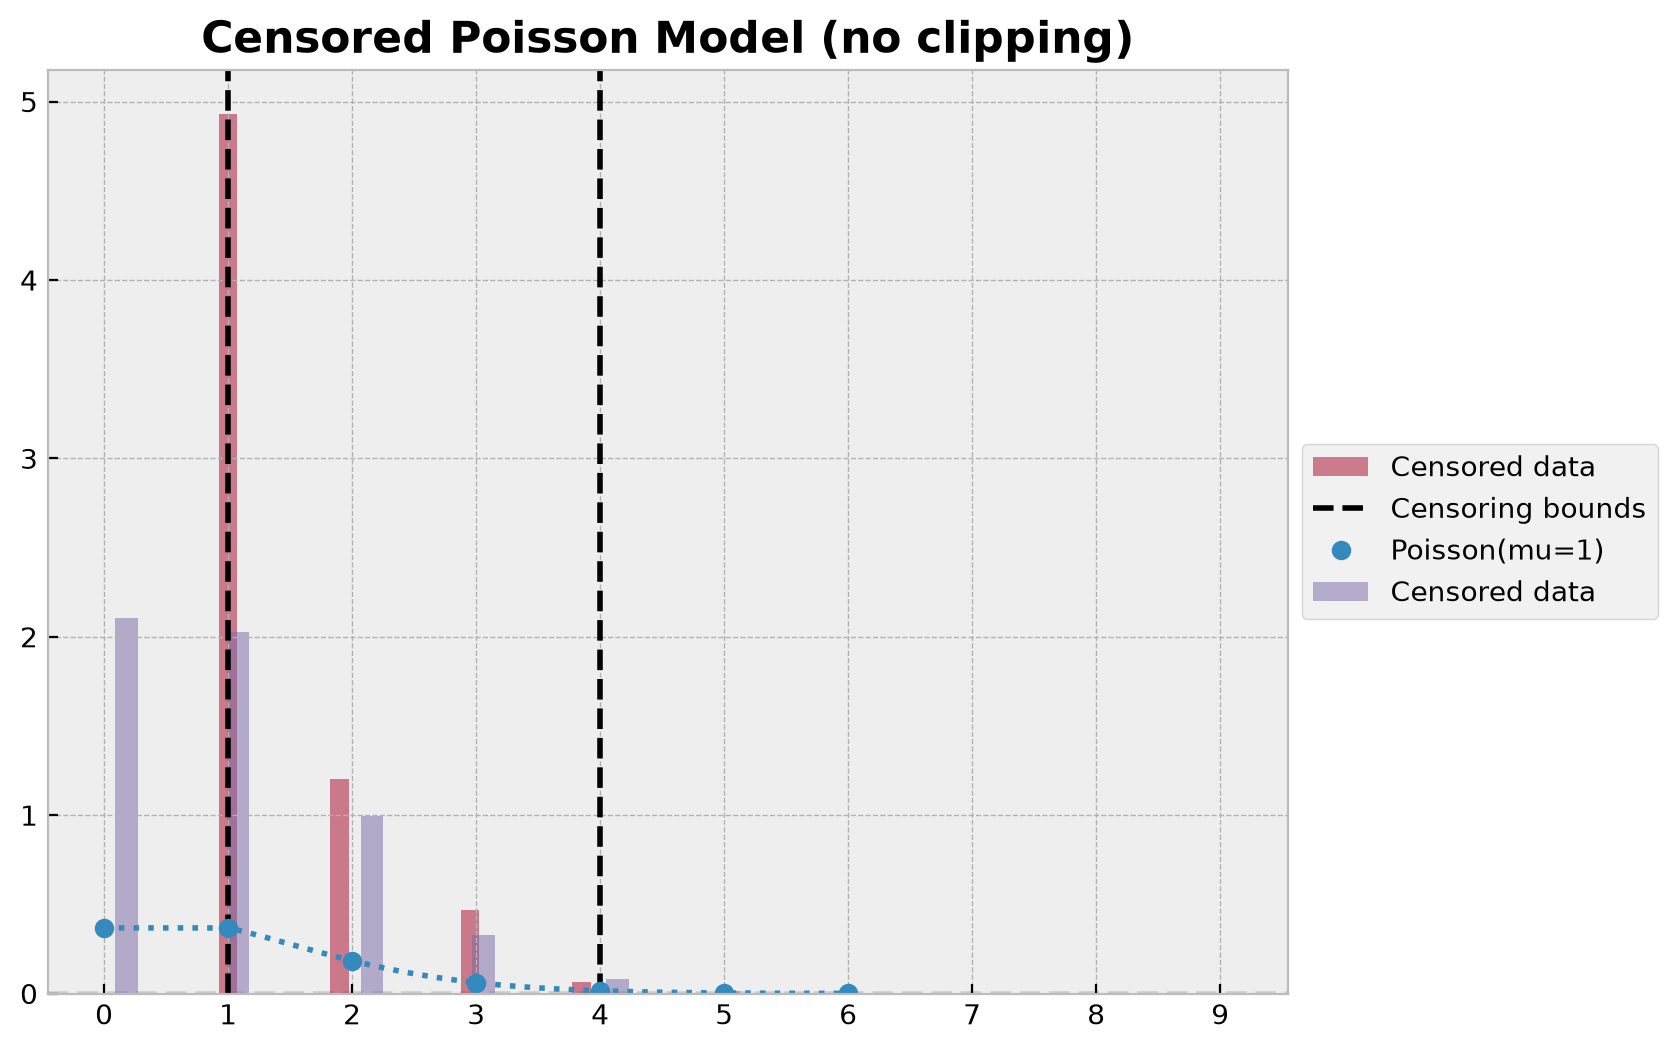

In [29]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_poisson_samples,
    bins=20,
    density=True,
    align="left",
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_poisson_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_poisson_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Poisson(mu=censored_poisson_data_params.rate).plot_pdf(color="C0", ax=ax)
_ = ax.hist(
    censored_poisson_idata["posterior_predictive"]["obs"].to_numpy().flatten(),
    bins=50,
    density=True,
    align="right",
    color="C2",
    alpha=0.5,
    label="Censored data",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Censored Poisson Model (no clipping)", fontsize=16, fontweight="bold");

As before, to have a correct posterior predictive distribution we need to clip the samples to the bounds.

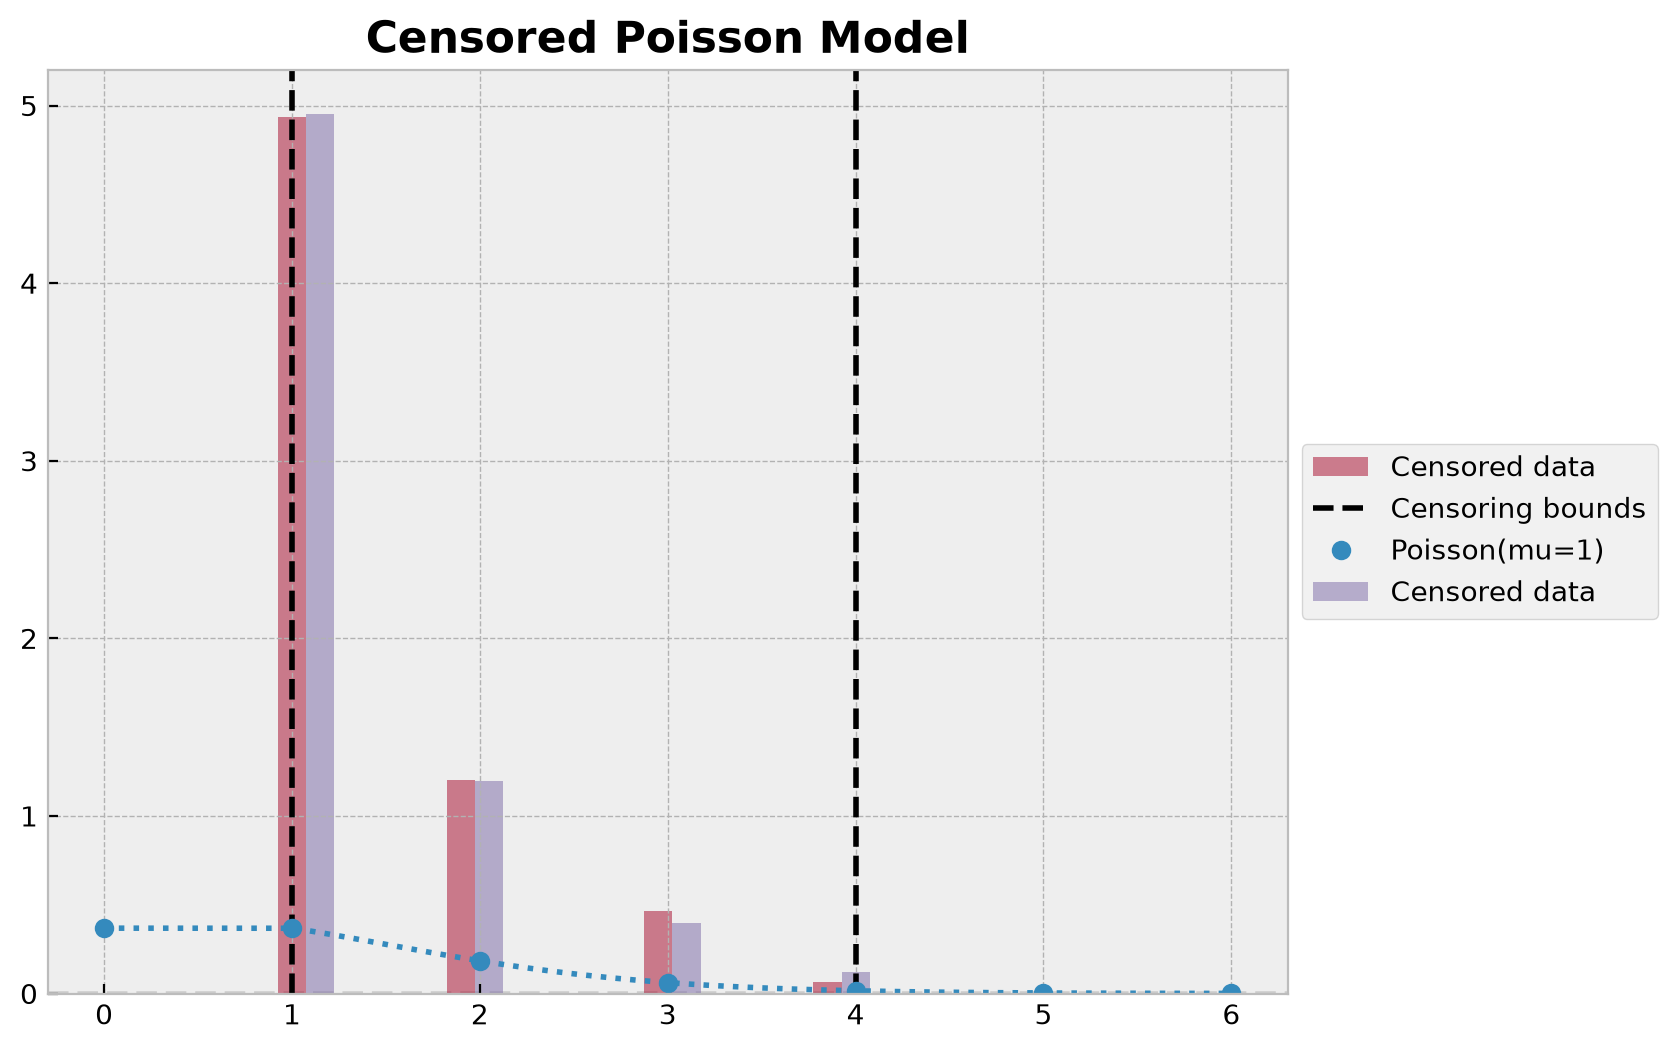

In [30]:
fig, ax = plt.subplots()
_ = ax.hist(
    censored_poisson_samples,
    bins=20,
    density=True,
    align="left",
    color="C1",
    alpha=0.5,
    label="Censored data",
)
ax.axvline(censored_poisson_data_params.lower, color="k", linestyle="--")
ax.axvline(
    censored_poisson_data_params.upper,
    color="k",
    linestyle="--",
    label="Censoring bounds",
)
pz.Poisson(mu=censored_poisson_data_params.rate).plot_pdf(color="C0", ax=ax)
_ = ax.hist(
    censored_poisson_idata["posterior_predictive"]["obs"]
    .clip(
        min=censored_poisson_data_params.lower, max=censored_poisson_data_params.upper
    )
    .to_numpy()
    .flatten(),
    bins=20,
    density=True,
    align="right",
    color="C2",
    alpha=0.5,
    label="Censored data",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Censored Poisson Model", fontsize=16, fontweight="bold");

Here we see that the observed and predicted distributions match well.